# 1. Visialisation

In [55]:
from graph_creation.adapters.output.geopandas_vis import graph_to_pandas, visualize_graph_geopandas
from graph_creation.adapters.input import GraphJsonLoader

In [56]:
gr = GraphJsonLoader().load("./final_graphs_data/final_graph/final_graph.json")
gr

Graph(type=UNDIRECTED, nodes=371, edges=5862, flights=84115, countries=30, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

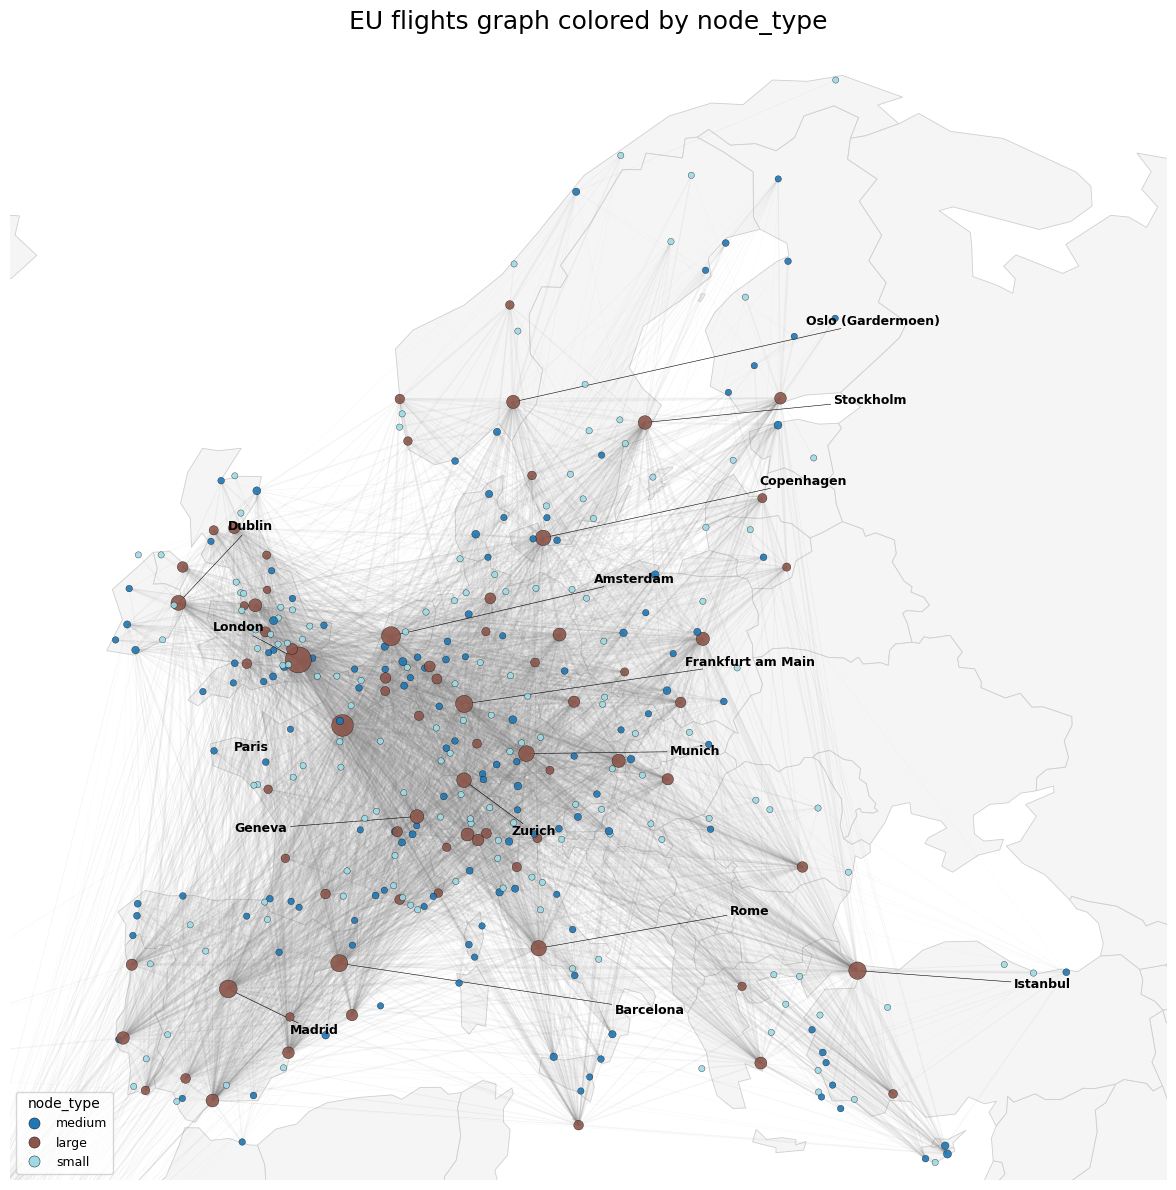

In [3]:
nodes_df, edges_df = graph_to_pandas(gr)
_ = visualize_graph_geopandas(nodes_df, edges_df)


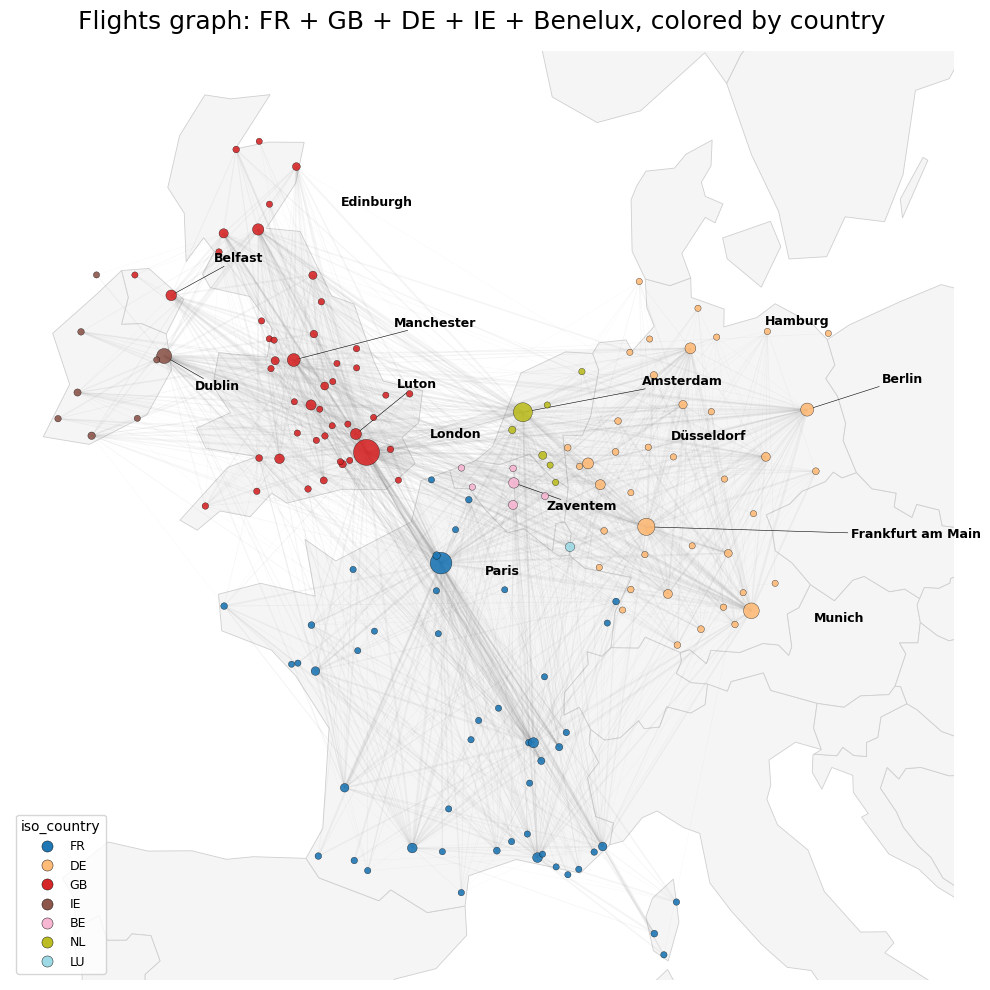

In [14]:
_ = visualize_graph_geopandas(
    nodes_df,
    edges_df,
    countries=["FR", "GB", "DE", "IE", "BE", "NL", "LU"],
    color_by="iso_country",
    size_by="node_degree",
    label_top_n=14,
    figsize=(15, 10),
    europe_xlim=(-11, 18),
    europe_ylim=(41, 59.5),
    title="Flights graph: FR + GB + DE + IE + Benelux, colored by country"
)

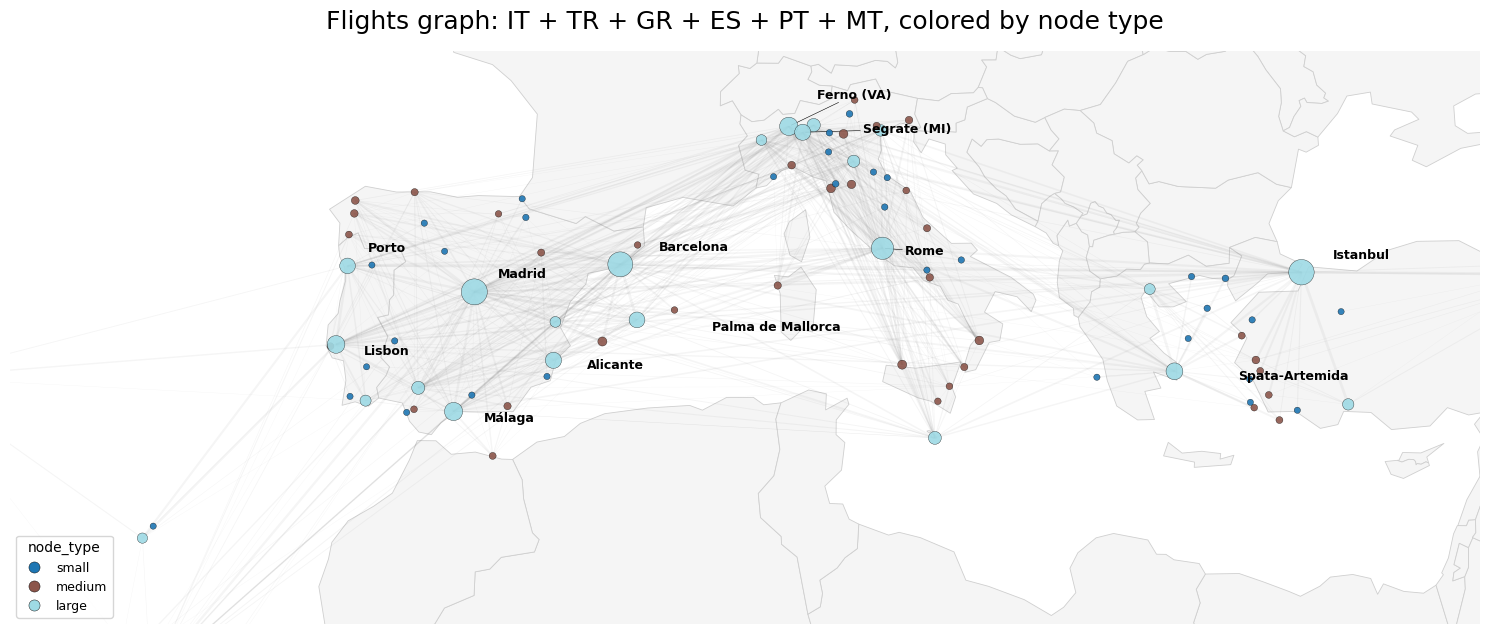

In [66]:
_ = visualize_graph_geopandas(
    nodes_df,
    edges_df,
    countries=["IT", "TR", "GR", "ES", "PT", "MT"],
    color_by="node_type",
    size_by="node_degree",
    label_top_n=12,
    figsize=(15, 8),
    europe_xlim=(-22, 36),
    europe_ylim=(30, 48),
    title="Flights graph: IT + TR + GR + ES + PT + MT, colored by node type"
)

I also have an html version of the graph. It was used for debaging, pandas version is much better. 

In [ ]:
# from graph_creation.adapters.output.folium_map import FoliumMapExporter
# FoliumMapExporter().export(gr, "final_graph")

# 2. Coverting the graph to nx graph

In [4]:
from graph_creation.adapters.input import GraphJsonLoader
from graph_creation.adapters.output.graph import NetworkXAdapter
import networkx as nx

gr = GraphJsonLoader().load("./final_graphs_data/final_graph/final_graph.json")
G = NetworkXAdapter.from_graph(gr)

print(G)
print(G.number_of_nodes(), G.number_of_edges())
print(list(G.nodes(data=True))[:3])
print(list(G.edges(data=True))[:3])

Graph with 371 nodes and 5862 edges
371 5862
[('Tymbou (Kirklar), CY', {'label': 'Tymbou (Kirklar)', 'name': 'Tymbou (Kirklar)', 'iso_country': 'CY', 'iso_region': 'CY-02', 'latitude': 35.153064, 'longitude': 33.507352, 'airports': ['LCEN'], 'traffic': 367, 'size': 367, 'node_type': 'medium', 'nuts3_code': None, 'degree': 6, 'weighted_degree': 367}), ('Warsaw, PL', {'label': 'Warsaw', 'name': 'Warsaw', 'iso_country': 'PL', 'iso_region': 'PL-MZ', 'latitude': 52.217449, 'longitude': 20.9371515, 'airports': ['EPBC', 'EPWA'], 'traffic': 2552, 'size': 2552, 'node_type': 'large', 'nuts3_code': None, 'degree': 101, 'weighted_degree': 2552}), ('Saint-Nazaire/Montoir, FR', {'label': 'Saint-Nazaire/Montoir', 'name': 'Saint-Nazaire/Montoir', 'iso_country': 'FR', 'iso_region': 'FR-PDL', 'latitude': 47.31142, 'longitude': -2.152634, 'airports': ['LFRZ'], 'traffic': 29, 'size': 29, 'node_type': 'small', 'nuts3_code': None, 'degree': 3, 'weighted_degree': 29})]
[('Tymbou (Kirklar), CY', 'Antalya, TR'

In [ ]:
# check graph properties. We checked many times during collection (notebook №1), but let's do it one more time

from collections import Counter

node_types = [data.get("node_type") for _, data in G.nodes(data=True)]
countries = [data.get("iso_country") for _, data in G.nodes(data=True)]

print("Node type counts:", Counter(node_types))
print("Country counts:", Counter(countries).most_common(10))
print("Missing coordinates:", sum(
    data.get("latitude") is None or data.get("longitude") is None
    for _, data in G.nodes(data=True)
))

Node type counts: Counter({'small': 151, 'medium': 144, 'large': 76})
Country counts: [('FR', 49), ('GB', 47), ('DE', 42), ('IT', 33), ('ES', 32), ('SE', 18), ('PL', 14), ('NO', 13), ('GR', 12), ('TR', 11)]
Missing coordinates: 0


# 3. Investigate node similarity, assortative mixing


## 3.1. Mixing: do hubs connect to hubs, or does the network look like hub-and-spoke?

### 3.1.1. Degree assortativity
For an air-traffic graph we should expect negative or slightly negative.

In [5]:
degree_assortativity = nx.degree_assortativity_coefficient(G)
print("Degree assortativity:", degree_assortativity)

Degree assortativity: -0.14551410699031422


Yes, we have negative assortativity = disassortative. But the value is not too small: disassortativity is present, but the graph is not a pure star-like system. Let's draw degree-corelation function.

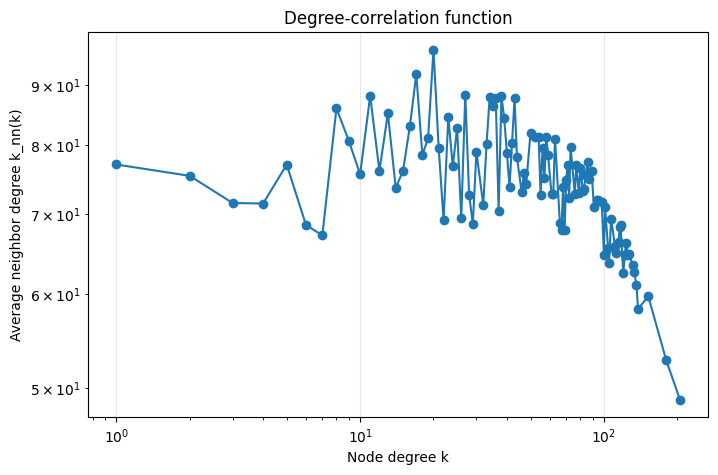

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

degree_dict = dict(G.degree())
avg_neighbor_degree = nx.average_neighbor_degree(G)

df_knn = pd.DataFrame({
    "node": list(degree_dict.keys()),
    "degree": [degree_dict[n] for n in degree_dict],
    "avg_neighbor_degree": [avg_neighbor_degree[n] for n in degree_dict],
})

knn_by_degree = (
    df_knn.groupby("degree", as_index=False)["avg_neighbor_degree"]
    .mean()
    .sort_values("degree")
)

plt.figure(figsize=(8, 5))
plt.plot(knn_by_degree["degree"], knn_by_degree["avg_neighbor_degree"], marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Node degree k")
plt.ylabel("Average neighbor degree k_nn(k)")
plt.title("Degree-correlation function")
plt.grid(True, alpha=0.3)
plt.show()

#### 3.1.1.1.Assortativity by airport class

In [7]:
node_type_assortativity = nx.attribute_assortativity_coefficient(G, "node_type")
print("Node-type assortativity:", node_type_assortativity)

Node-type assortativity: -0.023512933309347325


The results are equal to 0. So the graph is:clearly disassortative by degree, but only very weakly disassortative by node class.

We can suggest that “degree” and “node_type” are related, but not identical. Let's look:

In [8]:
import pandas as pd
from collections import Counter

rows = []
for u, v in G.edges():
    t_u = G.nodes[u].get("node_type")
    t_v = G.nodes[v].get("node_type")

    pair = tuple(sorted([t_u, t_v]))
    rows.append(pair)

mix_counter = Counter(rows)

mix_df = pd.DataFrame(
    [{"type_1": a, "type_2": b, "count": c} for (a, b), c in mix_counter.items()]
).sort_values("count", ascending=False)

mix_df.head(20)

,type_1,type_2,count
0,large,medium,2372
2,large,large,1930
3,large,small,579
1,medium,medium,569
5,medium,small,330
4,small,small,82


What we can see:
- many edges involve large airports,
- there are lots of large–medium and large–large links,
- very few small–small links.

So small airports are not forming their own separate local world. Instead, they are usually attached upward into the broader network. 

**Interpretation**: airport size classes are fairly mixed. The strongest interaction pattern is between large and medium nodes, while small-small connections are rare. This suggests that smaller airports are integrated into the network mainly through larger nodes rather than through dense peer-to-peer regional subnetworks.


That is exactly what we would expect in aviation.

## 3.2. Similarity: which airports/cities play similar structural roles? Jaccard similarity.
In this work, Jaccard similarity was selected as the main neighborhood-based similarity measure because it is simple, interpretable, and sufficient for comparing overlap in route neighborhoods.

In [10]:
preds = nx.jaccard_coefficient(G)

top_jaccard = sorted(preds, key=lambda x: x[2], reverse=True)[:20]

top_jaccard_rows = []
for u, v, score in top_jaccard:
    top_jaccard_rows.append({
        "node_1": u,
        "node_2": v,
        "jaccard": score,
        "country_1": G.nodes[u].get("iso_country"),
        "country_2": G.nodes[v].get("iso_country"),
        "type_1": G.nodes[u].get("node_type"),
        "type_2": G.nodes[v].get("node_type"),
        "degree_1": G.nodes[u].get("degree"),
        "degree_2": G.nodes[v].get("degree"),
    })

top_jaccard_df = pd.DataFrame(top_jaccard_rows)
top_jaccard_df.head(10)

,node_1,node_2,jaccard,country_1,country_2,type_1,type_2,degree_1,degree_2
0,"Røros, NO","Leirvik, NO",1.000000,NO,NO,small,small,1,1
1,"Kalymnos Island, GR","Kavala, GR",1.000000,GR,GR,small,small,1,1
2,"Samsun, TR","Edremit, TR",1.000000,TR,TR,small,small,1,1
3,"Kokkola / Kruunupyy, FI","Tartu, EE",1.000000,FI,EE,small,small,1,1
4,"Bodrum, TR","Selçuk, TR",0.714286,TR,TR,medium,medium,7,5
5,"Manchester, Greater Manchester, GB","Edinburgh, GB",0.606557,GB,GB,large,large,107,89
6,"Alicante, ES","Málaga, ES",0.582278,ES,ES,large,large,112,138
7,"Köln (Cologne), DE","Frankfurt am Main, DE",0.541096,DE,DE,large,large,98,127
8,"Ferno (VA), IT","Orio al Serio (BG), IT",0.528986,IT,IT,large,large,111,100
9,"Ferno (VA), IT","Segrate (MI), IT",0.524823,IT,IT,large,large,111,104


To study node similarity, we used the Jaccard coefficient based on overlap between node neighborhoods. The highest Jaccard values were observed for several pairs of nodes with very small degree, especially degree-1 nodes connected to the same neighbor. Although these pairs formally achieve perfect similarity, they are less informative structurally because the result is driven by extremely small local neighborhoods.

More meaningful patterns appear among medium- and high-degree nodes. For example, pairs such as Manchester–Edinburgh, Alicante–Málaga, Köln–Frankfurt, and several Italian airport pairs show high Jaccard similarity together with large degree values. This indicates that these nodes share a substantial part of their connection structure and likely play similar roles in the air transportation network.

Overall, the node similarity analysis suggests that structurally similar airports often belong to the same country or subregion and tend to occupy comparable positions in the network, such as major hubs or similarly connected regional nodes.

## 3.3. Conclusion (writen by chat gpt)

The assortativity and similarity analysis shows that the flight network has a predominantly hub-and-spoke structure. The degree assortativity coefficient is negative (-0.146), indicating that highly connected nodes tend to connect to less-connected ones. This conclusion is supported by the degree-correlation function k_{nn}(k), which decreases for large node degree values.

Assortativity by airport class is close to zero (-0.024), meaning that the network is not strongly segregated by node type. Instead, the most common interactions occur between large and medium airports, while small-small connections are relatively rare.

The Jaccard similarity analysis reveals that some pairs of airports have highly overlapping neighborhoods. While several perfect-similarity pairs are explained by trivial degree-1 cases, the more important result is that many medium- and high-degree airports within the same national or regional subsystem also exhibit strong neighborhood similarity. This suggests the presence of nodes with comparable structural roles in the European flight network.

# 4. Find communities using Louvain
To identify mesoscopic structure in the flight network, we applied the Louvain community detection algorithm to the weighted undirected graph. The algorithm partitions nodes into groups by maximizing modularity, so that nodes inside the same community are more densely connected to each other than to the rest of the network.

In [47]:
G = NetworkXAdapter.from_graph(gr)

communities = nx.community.louvain_communities(
    G,
    weight="weight",
    seed=42,
)

modularity = nx.community.modularity(G, communities, weight="weight")

print("Number of communities:", len(communities))
print("Modularity:", modularity)
print("Community sizes:", sorted([len(c) for c in communities], reverse=True))

Number of communities: 6
Modularity: 0.24385662755191517
Community sizes: [105, 81, 67, 66, 48, 4]


In [48]:
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

nx.set_node_attributes(G, community_map, "louvain_community")

community_sizes = Counter(community_map.values())
community_sizes_df = pd.DataFrame(
    [{"community": cid, "size": size} for cid, size in community_sizes.items()]
).sort_values("size", ascending=False)

community_sizes_df

,community,size
5,5,105
4,4,81
1,1,67
3,3,66
0,0,48
2,2,4


The Louvain algorithm detected **6 communities** in the weighted European flight network. The corresponding **modularity is 0.244**, which indicates a **meaningful but not sharply separated** community structure.

This is a realistic result for an air transportation network. On the one hand, the graph contains identifiable mesoscale groups of airports with denser internal connectivity. On the other hand, major international hubs create many long-range links, so the network does not split into perfectly isolated clusters.

The detected community sizes are **105, 81, 67, 66, 48, and 4** nodes. Most nodes belong to several medium-to-large communities, while one very small group appears as a clear outlier.

In [49]:
rows = []
for node, data in G.nodes(data=True):
    rows.append({
        "node": node,
        "community": data["louvain_community"],
        "country": data.get("iso_country"),
        "node_type": data.get("node_type"),
        "degree": G.degree(node),
        "weighted_degree": G.degree(node, weight="weight"),
    })

nodes_comm_df = pd.DataFrame(rows)

community_sizes_sorted = (
    community_sizes_df.sort_values("size", ascending=False)
    .reset_index(drop=True)
    .copy()
)

community_sizes_sorted["community_label"] = [
    "France + Spain",
    "Germany + Turkey",
    "UK + others",
    "Italy + Eastern Europe",
    "Northern Europe",
    "NATO military / outlier",
]

community_label_map = dict(
    zip(community_sizes_sorted["community"], community_sizes_sorted["community_label"])
)

nodes_comm_df["community_label"] = nodes_comm_df["community"].map(community_label_map)

nodes_comm_df.head()

,node,community,country,node_type,degree,weighted_degree,community_label
0,"Tymbou (Kirklar), CY",4,CY,medium,6,367,Germany + Turkey
1,"Warsaw, PL",3,PL,large,101,2552,Italy + Eastern Europe
2,"Saint-Nazaire/Montoir, FR",5,FR,small,3,29,France + Spain
3,"Skellefteå, SE",0,SE,medium,5,55,Northern Europe
4,"Memmingen, DE",3,DE,medium,40,158,Italy + Eastern Europe


To make the Louvain partition easier to interpret, we assign descriptive names to the detected communities based on their dominant geographic and structural patterns:

- **France + Spain** — 105 nodes  
- **Germany + Turkey** — 81 nodes  
- **UK + others** — 67 nodes  
- **Italy + Eastern Europe** — 66 nodes  
- **Northern Europe** — 48 nodes  
- **NATO military / outlier** — 4 nodes  

These names are **interpretive labels introduced for readability**. They are not produced by the Louvain algorithm itself. Since communities are defined by network structure rather than administrative borders, each group may still contain nodes from multiple countries.

In [50]:
# summary table block

community_summary = (
    nodes_comm_df.groupby(["community", "community_label"])
    .agg(
        size=("node", "count"),
        avg_degree=("degree", "mean"),
        avg_weighted_degree=("weighted_degree", "mean"),
    )
    .reset_index()
    .sort_values("size", ascending=False)
)

community_summary

,community,community_label,size,avg_degree,avg_weighted_degree
5,5,France + Spain,105,29.742857,402.600000
4,4,Germany + Turkey,81,32.641975,456.950617
1,1,UK + others,67,40.373134,666.328358
3,3,Italy + Eastern Europe,66,32.984848,342.136364
0,0,Northern Europe,48,21.958333,388.958333
2,2,NATO military / outlier,4,5.250000,21.750000


The community summary shows that the European flight network is organized into several large regional blocks rather than a single dominant cluster.

The largest group, **France + Spain**, contains **105 nodes** and represents the broadest regional subsystem in the network. The next three communities — **Germany + Turkey**, **UK + others**, and **Italy + Eastern Europe** — are of comparable size, which suggests that the graph has several important structural centers. **Northern Europe** is somewhat smaller but still substantial, while **NATO military / outlier** forms a very small peripheral component.

The average degree and weighted degree also differ across communities, which indicates that they are not only different in size, but also in their internal density and traffic intensity.

In [51]:
# dominant country / node type block

def top_value(series):
    vc = series.dropna().value_counts()
    return vc.index[0] if len(vc) > 0 else None

community_country = (
    nodes_comm_df.groupby("community")["country"]
    .apply(top_value)
    .reset_index(name="dominant_country")
)

community_type = (
    nodes_comm_df.groupby("community")["node_type"]
    .apply(top_value)
    .reset_index(name="dominant_node_type")
)

community_summary = (
    community_summary
    .merge(community_country, on="community", how="left")
    .merge(community_type, on="community", how="left")
)

community_summary = community_summary.sort_values("size", ascending=False)
community_summary

,community,community_label,size,avg_degree,avg_weighted_degree,dominant_country,dominant_node_type
0,5,France + Spain,105,29.742857,402.600000,FR,small
1,4,Germany + Turkey,81,32.641975,456.950617,DE,small
2,1,UK + others,67,40.373134,666.328358,GB,medium
3,3,Italy + Eastern Europe,66,32.984848,342.136364,IT,medium
4,0,Northern Europe,48,21.958333,388.958333,SE,medium
5,2,NATO military / outlier,4,5.250000,21.750000,GB,small


The dominant-country and dominant-node-type statistics help translate the graph partition into more interpretable real-world patterns.

The results confirm that the detected communities are **partly geographic, but not purely national**. For example, a group labeled **Germany + Turkey** may still include important nodes from several other countries. This reflects the fact that the Louvain partition is driven by connection structure and traffic intensity rather than by country boundaries alone.

The dominant airport classes are mostly **small** or **medium**, which suggests that communities are not defined only by major hubs. Instead, each region combines large connectors with broader layers of medium and smaller airports.

In [52]:
# hub block

top_hubs = (
    nodes_comm_df.sort_values(["community", "weighted_degree"], ascending=[True, False])
    .groupby("community")
    .first()
    .reset_index()[["community", "node", "country", "weighted_degree"]]
    .rename(columns={
        "node": "top_hub",
        "country": "top_hub_country",
        "weighted_degree": "top_hub_weighted_degree"
    })
)

community_summary = community_summary.merge(top_hubs, on="community", how="left")
community_summary = community_summary.sort_values("size", ascending=False)

community_summary

,community,community_label,size,avg_degree,avg_weighted_degree,dominant_country,dominant_node_type,top_hub,top_hub_country,top_hub_weighted_degree
0,5,France + Spain,105,29.742857,402.600000,FR,small,"Paris, FR",FR,7877
1,4,Germany + Turkey,81,32.641975,456.950617,DE,small,"Istanbul, TR",TR,4849
2,1,UK + others,67,40.373134,666.328358,GB,medium,"London, GB",GB,11694
3,3,Italy + Eastern Europe,66,32.984848,342.136364,IT,medium,"Rome, IT",IT,3639
4,0,Northern Europe,48,21.958333,388.958333,SE,medium,"Copenhagen, DK",DK,3688
5,2,NATO military / outlier,4,5.250000,21.750000,GB,small,"Carterton, Oxfordshire, GB",GB,37


To better understand the internal organization of each community, we identify the node with the highest weighted degree inside every group. These nodes represent the strongest traffic hubs within their respective subnetworks.

This analysis is useful because it shows that each named community is centered around a meaningful aviation core. Even when the community label reflects its dominant geographic character, the top hub reveals the actual structural center of traffic concentration inside that part of the network.

Therefore, the Louvain communities can be interpreted not as arbitrary graph fragments, but as regional traffic structures organized around major hubs.

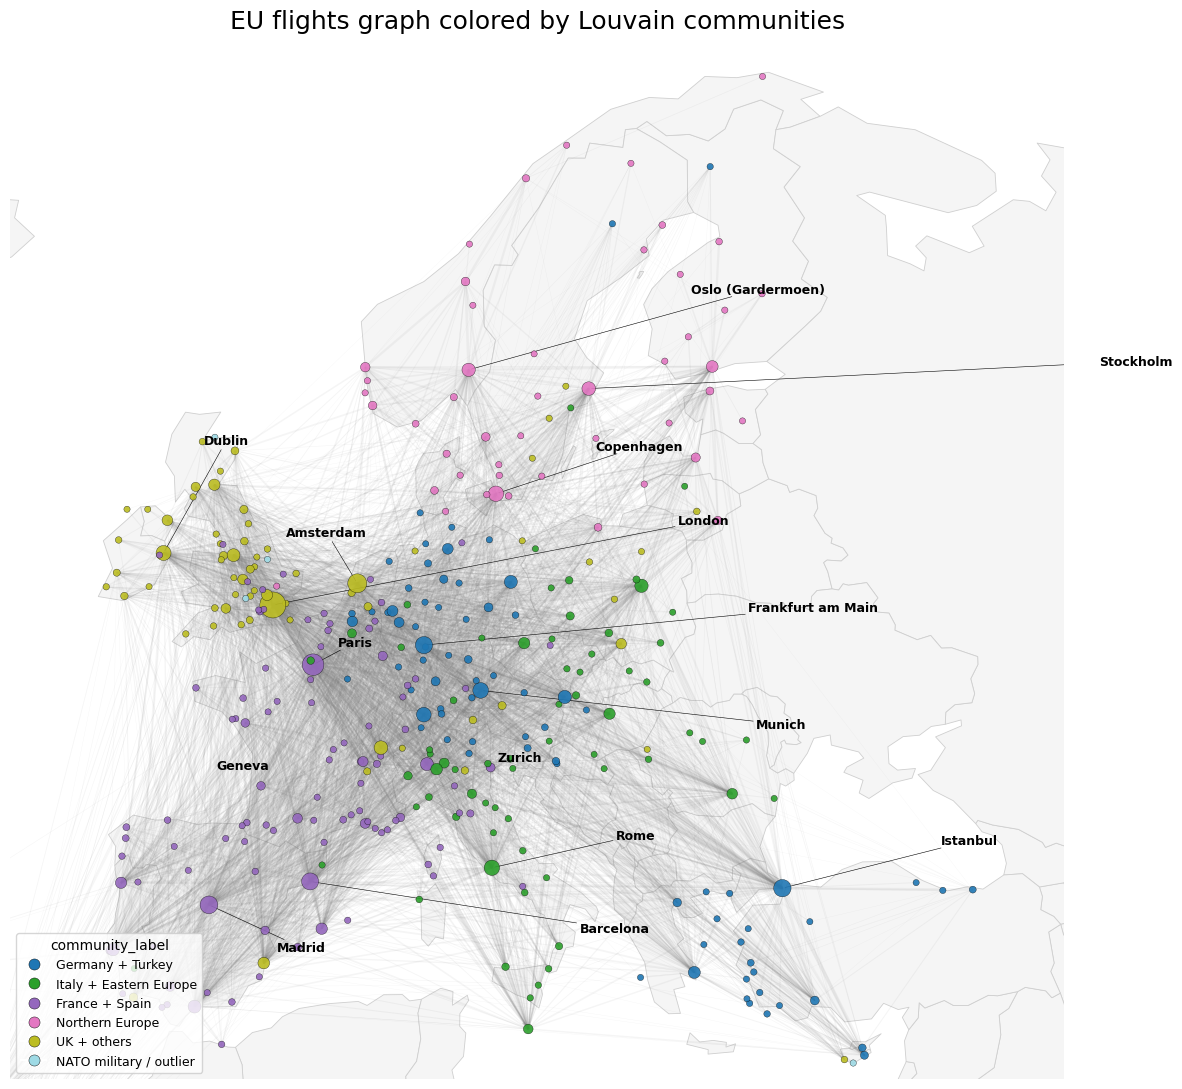

In [53]:
# visualisation
from graph_creation.adapters.output.geopandas_vis import graph_to_pandas, visualize_graph_geopandas

nodes_df, edges_df = graph_to_pandas(gr)

community_df = pd.DataFrame(
    [
        {
            "id": node,
            "louvain_community": cid,
            "community_label": community_label_map[cid],
        }
        for node, cid in community_map.items()
    ]
)

nodes_df = nodes_df.merge(community_df, on="id", how="left")

_ = visualize_graph_geopandas(
    nodes_df,
    edges_df,
    color_by="community_label",
    size_by="node_degree",
    label_top_n=15,
    figsize=(18, 11),
    europe_xlim=(-15, 45),
    europe_ylim=(34, 72),
    title="EU flights graph colored by Louvain communities"
)

The geographic visualization of the Louvain partition makes the community structure much easier to interpret. The named communities — such as **France + Spain**, **Germany + Turkey**, and **Northern Europe** — clearly correspond to broad regional patterns, but they are not perfectly compact geographic clusters.

This is expected for a flight network. Geography matters, because nearby airports often belong to the same traffic subsystem. However, the final community structure is also shaped by **hub dominance, airline routing logic, and cross-border connectivity**.

Therefore, the detected Louvain groups should be interpreted as **network regions**, not simply as geographic regions on the map.

In [54]:
bridge_rows = []

for u, v, data in G.edges(data=True):
    cu = community_map[u]
    cv = community_map[v]

    if cu == cv:
        continue

    label_u = community_label_map[cu]
    label_v = community_label_map[cv]

    comm_1, comm_2 = sorted([label_u, label_v])

    bridge_rows.append({
        "community_1": comm_1,
        "community_2": comm_2,
        "weight": data.get("weight", 1),
    })

bridges_df = pd.DataFrame(bridge_rows)

if len(bridges_df) > 0:
    bridge_summary = (
        bridges_df.groupby(["community_1", "community_2"], as_index=False)
        .agg(
            edge_count=("weight", "count"),
            total_weight=("weight", "sum"),
        )
        .sort_values("total_weight", ascending=False)
    )

    display(bridge_summary.head(15))
else:
    print("No inter-community edges found.")

,community_1,community_2,edge_count,total_weight
4,France + Spain,UK + others,637,8633
0,France + Spain,Germany + Turkey,532,6590
8,Germany + Turkey,UK + others,452,6552
11,Italy + Eastern Europe,UK + others,420,4939
1,France + Spain,Italy + Eastern Europe,474,4831
5,Germany + Turkey,Italy + Eastern Europe,416,4317
13,Northern Europe,UK + others,210,3092
7,Germany + Turkey,Northern Europe,213,2666
3,France + Spain,Northern Europe,156,1470
10,Italy + Eastern Europe,Northern Europe,141,1198


To understand how the detected Louvain communities interact with each other, we analyzed all **inter-community edges**, that is, edges connecting nodes belonging to different communities. For each pair of named communities, we computed:

- the **number of bridge edges** (`edge_count`),
- the **total traffic weight** on these edges (`total_weight`).

This analysis shows which regional subnetworks are most strongly connected to each other.

The strongest bridge pairs correspond to the main structural blocks of the European flight graph. In particular, large communities such as **France + Spain**, **Germany + Turkey**, **Italy + Eastern Europe**, and **Northern Europe** exchange substantial traffic with one another. This means that the community structure is meaningful, but the communities are **not isolated modules**. Instead, they form an interconnected system linked through high-weight cross-community routes.

By contrast, the **NATO military / outlier** community has much weaker bridge connectivity, which supports its interpretation as a small peripheral or special-purpose fragment rather than a central part of the main network. This is because i filtered the graph from military bases, but some of them remain in the network.

## 4* Conclusion

The Louvain algorithm identified **6 communities** in the weighted European flight network, with **modularity 0.244**, indicating a meaningful but not sharply separated community structure. This is a realistic result for air transportation, where regional subnetworks exist, but remain strongly linked through major international hubs.

To improve interpretability, the detected communities were assigned descriptive names: **France + Spain**, **Germany + Turkey**, **UK + others**, **Italy + Eastern Europe**, **Northern Europe**, and **UK military / outlier**. These names summarize the dominant geographic character of each group, while acknowledging that the communities are defined by graph structure rather than strict national borders.

The community statistics show that the network is organized into several major regional blocks of comparable scale. At the same time, the groups differ in density and traffic intensity, which indicates that the detected communities are structurally distinct, not only geographically different.

The geographic visualization confirms that the Louvain partition is **partly geographic and partly functional**. Communities often align with broad European regions, but they also cross country borders and reflect the real organization of air traffic around major hubs. The bridge analysis further shows that the largest communities remain strongly interconnected, so the overall graph should be interpreted as a system of **interacting regional traffic structures** rather than isolated clusters.

Overall, the Louvain analysis demonstrates that the European flight graph has a clear mesoscale organization. Its communities capture meaningful regional and functional patterns in the route network while preserving the strong interdependence created by large hubs and long-distance connections.

# 5. ML tasks
(node classification/link prediction/etc., check several models/approaches)

## 5.1. Node classification: small, medium, large
### 5.1.1 Feature selection

In [73]:
from graph_creation.adapters.input import GraphJsonLoader
graph_cls = GraphJsonLoader().load("./final_graphs_data/gr_for_label_prediction/gr_for_label_prediction.json")
graph_cls

Graph(type=UNDIRECTED, nodes=368, edges=5766, flights=83454, countries=30, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

In [74]:
graph_cls.node_types # large class is small enough 

Counter({'small': 150, 'medium': 144, 'large': 74})

In [75]:
import networkx as nx
import pandas as pd

G = NetworkXAdapter.from_graph(graph_cls)

degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))
clustering = nx.clustering(G)
pagerank = nx.pagerank(G, weight="weight")
betweenness = nx.betweenness_centrality(G, weight="weight")
closeness = nx.closeness_centrality(G)
core_number = nx.core_number(G)
avg_neighbor_degree = nx.average_neighbor_degree(G)

rows = []
for node, data in G.nodes(data=True):
    rows.append({
        "id": node,
        "target": data["node_type"],
        "degree": degree[node],
        "weighted_degree": weighted_degree[node],
        "clustering": clustering[node],
        "pagerank": pagerank[node],
        "betweenness": betweenness[node],
        "closeness": closeness[node],
        "core_number": core_number[node],
        "avg_neighbor_degree": avg_neighbor_degree[node],
        "iso_country": data.get("iso_country"),
        "latitude": data.get("latitude"),
        "longitude": data.get("longitude"),
    })

df_cls = pd.DataFrame(rows)
df_cls.head()

,id,target,degree,weighted_degree,clustering,pagerank,betweenness,closeness,core_number,avg_neighbor_degree,iso_country,latitude,longitude
0,"Tymbou (Kirklar), CY",medium,6,367,0.800000,0.002130,0.000000,0.376025,5,37.333333,CY,35.153064,33.507352
1,"Warsaw, PL",large,100,2543,0.436566,0.013399,0.004842,0.569876,38,70.430000,PL,52.217449,20.937151
2,"Saint-Nazaire/Montoir, FR",small,3,29,0.333333,0.000811,0.000000,0.381894,2,58.000000,FR,47.311420,-2.152634
3,"Skellefteå, SE",medium,5,55,0.400000,0.000690,0.001370,0.385504,4,58.200000,SE,64.624802,21.076900
4,"Memmingen, DE",medium,40,158,0.544872,0.001444,0.007645,0.499320,31,81.800000,DE,47.988092,10.238248


In [78]:
# Numeric summary by class = EDA
summary_by_class = (
    df_cls.groupby("target")[[
        "degree",
        "weighted_degree",
        "clustering",
        "pagerank",
        "betweenness",
        "closeness",
        "core_number",
        "avg_neighbor_degree",
    ]]
    .agg(["mean", "median", "std"])
)

summary_by_class

degree                   weighted_degree                       \
             mean median        std            mean  median          std   
target                                                                     
large   89.932432   84.0  32.644759     1899.135135  1303.0  1835.745702   
medium  26.472222   24.0  17.501626      145.458333   101.5   117.211415   
small    7.100000    5.0   6.378182       16.426667    13.5    12.642926   

       clustering                      pagerank  ... betweenness closeness  \
             mean    median       std      mean  ...         std      mean   
target                                           ...                         
large    0.439200  0.446519  0.089283  0.009943  ...    0.008429  0.556087   
medium   0.558534  0.546827  0.159837  0.001238  ...    0.006791  0.464872   
small    0.452767  0.439145  0.315556  0.000573  ...    0.002334  0.401271   

                           core_number                   avg_neighbor_degree  \
          median       std        mean median        std                mean   
target                                                                         
large   0.556062  0.039083   36.959459   38.0   3.654381           70.973348   
medium  0.466624  0.039177   20.180556   20.0  10.448443           79.442486   
small   0.404186  0.035960    6.460000    5.0   5.215658           73.451962   

                              
           median        std  
target                        
large   71.709207   7.607268  
medium  79.453297  15.013141  
small   74.800000  27.767636  

[3 rows x 24 columns]

<Figure size 700x400 with 0 Axes>

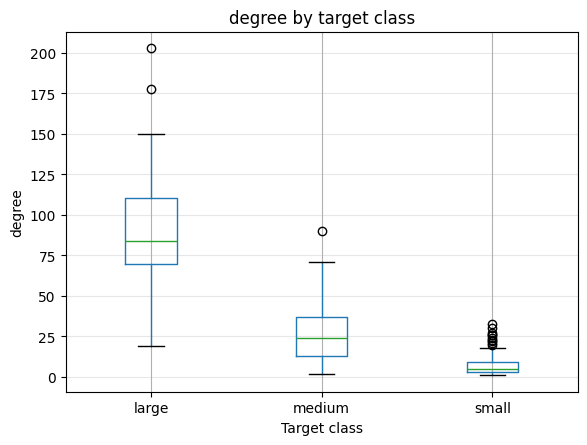

<Figure size 700x400 with 0 Axes>

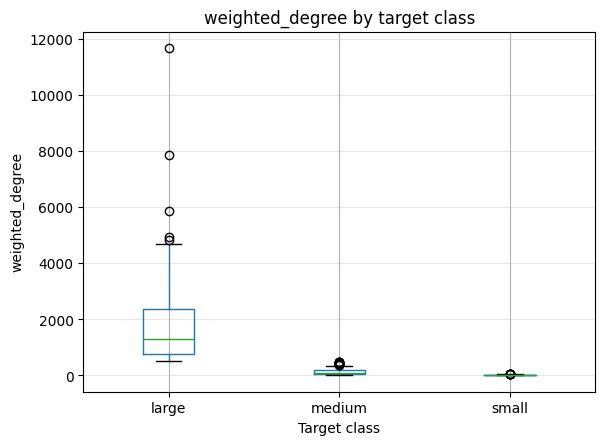

<Figure size 700x400 with 0 Axes>

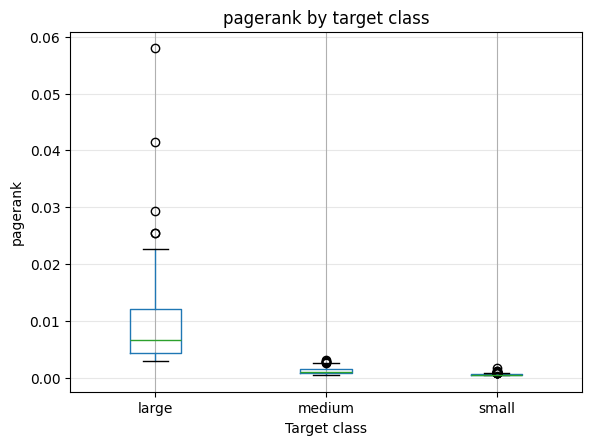

<Figure size 700x400 with 0 Axes>

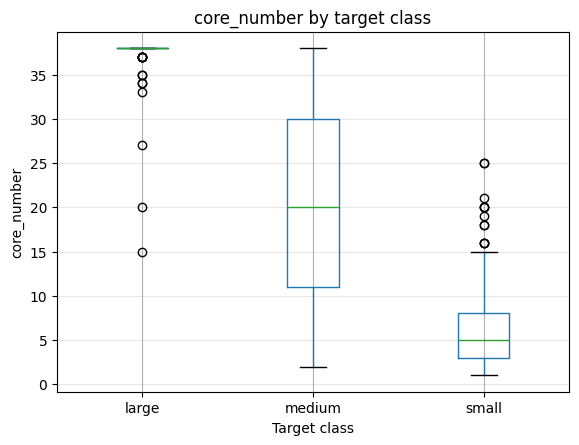

In [79]:
import matplotlib.pyplot as plt

features_to_plot = [
    "degree",
    "weighted_degree",
    "pagerank",
    "core_number",
]

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    df_cls.boxplot(column=feature, by="target")
    plt.title(f"{feature} by target class")
    plt.suptitle("")  # removes automatic pandas subtitle
    plt.xlabel("Target class")
    plt.ylabel(feature)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

In [80]:
from sklearn.preprocessing import LabelEncoder

feature_cols = [
    "degree",
    "weighted_degree",
    "clustering",
    "pagerank",
    "betweenness",
    "closeness",
    "core_number",
    "avg_neighbor_degree",
]

X = df_cls[feature_cols].copy()
y_raw = df_cls["target"].copy()

# Encode labels: small / medium / large -> integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print("Classes:", list(label_encoder.classes_))
print("X shape:", X.shape)
print("y shape:", y.shape)

Classes: ['large', 'medium', 'small']
X shape: (368, 8)
y shape: (368,)


In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X,
    y,
    df_cls[["id", "target"]],
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print("Train class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("Test class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train size: 294
Test size: 74
Train class distribution:
0     59
1    115
2    120
Name: count, dtype: int64
Test class distribution:
0    15
1    29
2    30
Name: count, dtype: int64


### 5.2 Baselines
#### 5.2.1. Dummy Classifier

In [82]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Majority baseline")
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Macro F1:", f1_score(y_test, y_pred_dummy, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred_dummy, average="weighted"))
print()
print(classification_report(y_test, y_pred_dummy, target_names=label_encoder.classes_))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_dummy))

Majority baseline
Accuracy: 0.40540540540540543
Macro F1: 0.1923076923076923
Weighted F1: 0.23388773388773387

              precision    recall  f1-score   support

       large       0.00      0.00      0.00        15
      medium       0.00      0.00      0.00        29
       small       0.41      1.00      0.58        30

    accuracy                           0.41        74
   macro avg       0.14      0.33      0.19        74
weighted avg       0.16      0.41      0.23        74

Confusion matrix:
[[ 0  0 15]
 [ 0  0 29]
 [ 0  0 30]]


/Users/dmitrijkanevskij/VS_CodeProjects/data_science/agents_graphs_dl/courses/eu_flights/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dmitrijkanevskij/VS_CodeProjects/data_science/agents_graphs_dl/courses/eu_flights/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dmitrijkanevskij/VS_CodeProjects/data_science/agents_graphs_dl/courses/eu_flights/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: P

#### 5.2.2. Logistic Regression

In [84]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    )),
])

logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Macro F1:", f1_score(y_test, y_pred_logreg, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred_logreg, average="weighted"))
print()
print(classification_report(y_test, y_pred_logreg, target_names=label_encoder.classes_))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

Logistic Regression
Accuracy: 0.8108108108108109
Macro F1: 0.8232193732193732
Weighted F1: 0.8108974358974358

              precision    recall  f1-score   support

       large       1.00      0.80      0.89        15
      medium       0.78      0.72      0.75        29
       small       0.77      0.90      0.83        30

    accuracy                           0.81        74
   macro avg       0.85      0.81      0.82        74
weighted avg       0.82      0.81      0.81        74

Confusion matrix:
[[12  3  0]
 [ 0 21  8]
 [ 0  3 27]]


#### 5.2.3. Random Forest baseline

In [85]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced",
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred_rf, average="weighted"))
print()
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9324324324324325
Macro F1: 0.9432419432419432
Weighted F1: 0.9321984321984321

              precision    recall  f1-score   support

       large       1.00      1.00      1.00        15
      medium       0.96      0.86      0.91        29
       small       0.88      0.97      0.92        30

    accuracy                           0.93        74
   macro avg       0.95      0.94      0.94        74
weighted avg       0.94      0.93      0.93        74

Confusion matrix:
[[15  0  0]
 [ 0 25  4]
 [ 0  1 29]]


In [87]:
rf_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

rf_feature_importance

,feature,importance
1,weighted_degree,0.365006
3,pagerank,0.222835
5,closeness,0.129207
0,degree,0.109004
6,core_number,0.094704
4,betweenness,0.035509
2,clustering,0.026412
7,avg_neighbor_degree,0.017323


#### Results

In [86]:
results = pd.DataFrame([
    {
        "model": "Majority baseline",
        "accuracy": accuracy_score(y_test, y_pred_dummy),
        "macro_f1": f1_score(y_test, y_pred_dummy, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred_dummy, average="weighted"),
    },
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, y_pred_logreg),
        "macro_f1": f1_score(y_test, y_pred_logreg, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred_logreg, average="weighted"),
    },
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "macro_f1": f1_score(y_test, y_pred_rf, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred_rf, average="weighted"),
    },
]).sort_values("macro_f1", ascending=False)

results

,model,accuracy,macro_f1,weighted_f1
2,Random Forest,0.932432,0.943242,0.932198
1,Logistic Regression,0.810811,0.823219,0.810897
0,Majority baseline,0.405405,0.192308,0.233888


### 5.3. Conclusion (written by chatgpt)

In this experiment, we considered the problem of **node label classification** on the cleaned undirected European flight graph. The goal was to predict the node class — **small**, **medium**, or **large** — using only structural information derived from the network.

To represent each node, we constructed a set of graph-based features, including **degree**, **weighted degree**, **clustering coefficient**, **PageRank**, **betweenness centrality**, **closeness centrality**, **core number**, and **average neighbor degree**. These features capture both local connectivity and the broader structural role of a node in the graph.

We evaluated three baseline models: a **majority-class classifier**, **Logistic Regression**, and **Random Forest**. Since the class distribution is moderately imbalanced, the main evaluation metric was **macro F1**, which gives equal importance to all classes.

The majority baseline achieved only **0.405 accuracy** and **0.192 macro F1**, which shows that naive prediction is not sufficient for this task. In contrast, **Logistic Regression** reached **0.811 accuracy** and **0.823 macro F1**, already demonstrating that airport class is strongly related to graph structure. The best result was obtained by **Random Forest**, which achieved **0.932 accuracy**, **0.943 macro F1**, and **0.932 weighted F1** on the test set.

The class-wise results of Random Forest are also strong:
- **large**: F1 = **1.00**
- **medium**: F1 = **0.91**
- **small**: F1 = **0.92**

This means that the model almost perfectly identifies large airports and also separates medium and small airports very well. The remaining classification difficulty is concentrated mainly between the **medium** and **small** classes, which is expected because these categories are structurally closer than clearly dominant large hubs + problems with data collection from free sources.

Feature importance analysis confirms this interpretation. The most important predictors were:

- **weighted_degree**: **0.365**
- **pagerank**: **0.223**
- **closeness**: **0.129**
- **degree**: **0.109**
- **core_number**: **0.095**

These results indicate that the node category is primarily determined by how many flights it handels. Surprise, who might think about this :)


## 5.2. Node regression: pps per capita prediction
### 5.2.1. Feature selection

In [ ]:
import pandas as pd
import networkx as nx

from graph_creation.adapters.input import GraphJsonLoader
from graph_creation.adapters.output.graph import NetworkXAdapter

graph_pps = GraphJsonLoader().load("./final_graphs_data/ready_gr_for_nuts3/ready_gr_for_nuts3.json")
G = NetworkXAdapter.from_graph(graph_pps)
print(G)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# Load PPS target table
pps_df = pd.read_csv("./final_graphs_data/ready_gr_for_nuts3/nuts3_in_use_pps.csv")
print(pps_df.shape)
pps_df.head()

Graph with 247 nodes and 3660 edges
Nodes: 247
Edges: 3660
(194, 3)


,nut3_code,pps,pps_per_inhabitant
0,AT13,110239.09,54600.0
1,AT22,56434.90,44400.0
2,AT31,72868.24,47500.0
3,AT32,33250.22,58100.0
4,AT33,39556.06,50900.0


In [95]:
from collections import Counter

Counter(pd.Series([n.nut3_code for n in graph_pps.nodes]).value_counts().values)

Counter({np.int64(1): 157,
         np.int64(2): 25,
         np.int64(3): 9,
         np.int64(4): 2,
         np.int64(5): 1})

In [ ]:
# graph-derived node features
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))
clustering = nx.clustering(G, weight=None)
pagerank = nx.pagerank(G, weight="weight")
betweenness = nx.betweenness_centrality(G, weight="weight")
closeness = nx.closeness_centrality(G)
core_number = nx.core_number(G)
avg_neighbor_degree = nx.average_neighbor_degree(G, weight=None)

# Louvain communities
communities = nx.community.louvain_communities(G, weight="weight", seed=42)
community_map = {}
for cid, comm in enumerate(communities):
    for node in comm:
        community_map[node] = cid

community_sizes = Counter(community_map.values())

In [ ]:
# distance- and neighborhood-based features

import numpy as np

def safe_mean(values):
    vals = [v for v in values if pd.notna(v)]
    return float(np.mean(vals)) if len(vals) > 0 else np.nan

def safe_std(values):
    vals = [v for v in values if pd.notna(v)]
    return float(np.std(vals)) if len(vals) > 0 else np.nan

def safe_max(values):
    vals = [v for v in values if pd.notna(v)]
    return float(np.max(vals)) if len(vals) > 0 else np.nan

# Europe-ish centroid for a simple geographic reference feature
EUROPE_CENTROID_LAT = 54.0
EUROPE_CENTROID_LON = 15.0

def euclidean_geo_distance(lat1, lon1, lat2, lon2):
    if any(pd.isna(x) for x in [lat1, lon1, lat2, lon2]):
        return np.nan
    return float(np.sqrt((lat1 - lat2) ** 2 + (lon1 - lon2) ** 2))

rows = []

for node, data in G.nodes(data=True):
    nut3_code = data.get("nuts3_code") or data.get("nut3_code")
    if nut3_code is None:
        continue

    lat = data.get("latitude")
    lon = data.get("longitude")

    neighbors = list(G.neighbors(node))
    edge_weights = []
    edge_distances = []

    neighbor_degrees = []
    neighbor_weighted_degrees = []
    neighbor_pageranks = []
    neighbor_latitudes = []
    neighbor_longitudes = []

    long_edges_500 = 0
    long_edges_1000 = 0
    short_edges_300 = 0

    for nb in neighbors:
        e = G[node][nb]

        w = e.get("weight", 1)
        d = e.get("distance", np.nan)

        edge_weights.append(w)
        edge_distances.append(d)

        neighbor_degrees.append(degree[nb])
        neighbor_weighted_degrees.append(weighted_degree[nb])
        neighbor_pageranks.append(pagerank[nb])

        nb_lat = G.nodes[nb].get("latitude")
        nb_lon = G.nodes[nb].get("longitude")
        neighbor_latitudes.append(nb_lat)
        neighbor_longitudes.append(nb_lon)

        if pd.notna(d):
            if d <= 300:
                short_edges_300 += 1
            if d >= 500:
                long_edges_500 += 1
            if d >= 1000:
                long_edges_1000 += 1

    node_degree = degree[node]

    rows.append({
        "id": node,
        "nut3_code": str(nut3_code),

        # target merged later
        "degree": node_degree,
        "weighted_degree": weighted_degree[node],
        "traffic_per_neighbor": weighted_degree[node] / node_degree if node_degree > 0 else 0.0,

        "clustering": clustering[node],
        "pagerank": pagerank[node],
        "betweenness": betweenness[node],
        "closeness": closeness[node],
        "core_number": core_number[node],
        "avg_neighbor_degree": avg_neighbor_degree[node],

        "louvain_community": community_map.get(node),
        "louvain_community_size": community_sizes.get(community_map.get(node), np.nan),

        "latitude": lat,
        "longitude": lon,
        "dist_to_europe_centroid": euclidean_geo_distance(
            lat, lon, EUROPE_CENTROID_LAT, EUROPE_CENTROID_LON
        ),

        "mean_edge_weight": safe_mean(edge_weights),
        "max_edge_weight": safe_max(edge_weights),
        "std_edge_weight": safe_std(edge_weights),

        "mean_edge_distance": safe_mean(edge_distances),
        "max_edge_distance": safe_max(edge_distances),
        "std_edge_distance": safe_std(edge_distances),

        "share_short_edges_300": short_edges_300 / node_degree if node_degree > 0 else np.nan,
        "share_long_edges_500": long_edges_500 / node_degree if node_degree > 0 else np.nan,
        "share_long_edges_1000": long_edges_1000 / node_degree if node_degree > 0 else np.nan,

        "mean_neighbor_degree": safe_mean(neighbor_degrees),
        "mean_neighbor_weighted_degree": safe_mean(neighbor_weighted_degrees),
        "mean_neighbor_pagerank": safe_mean(neighbor_pageranks),

        "mean_neighbor_latitude": safe_mean(neighbor_latitudes),
        "mean_neighbor_longitude": safe_mean(neighbor_longitudes),
    })

df_reg = pd.DataFrame(rows)

print(df_reg.shape)
df_reg.head()

(247, 30)


,id,nut3_code,degree,weighted_degree,traffic_per_neighbor,clustering,pagerank,betweenness,closeness,core_number,...,max_edge_distance,std_edge_distance,share_short_edges_300,share_long_edges_500,share_long_edges_1000,mean_neighbor_degree,mean_neighbor_weighted_degree,mean_neighbor_pagerank,mean_neighbor_latitude,mean_neighbor_longitude
0,"Tymbou (Kirklar), CY",CY000,6,367,61.166667,0.800000,0.003390,0.000000,0.389857,5,...,850.61,170.084939,0.000000,0.833333,0.000000,31.166667,876.833333,0.007811,38.730011,30.283012
1,"Warsaw, PL",PL91,82,2223,27.109756,0.478470,0.018569,0.006009,0.592771,31,...,3714.21,701.346166,0.073171,0.853659,0.475610,58.463415,1009.780488,0.008912,47.064201,12.075747
2,"Skellefteå, SE",SE331,4,54,13.500000,0.500000,0.001056,0.008183,0.395498,3,...,1148.68,343.142096,0.000000,0.750000,0.500000,55.750000,1292.500000,0.011671,57.974113,18.683941
3,"Memmingen, DE",DE27,37,135,3.648649,0.549550,0.001999,0.011832,0.515723,29,...,2418.38,586.753038,0.108108,0.729730,0.405405,64.216216,1203.972973,0.010543,44.832167,10.844519
4,"Brno, CZ",CZ064,16,36,2.250000,0.466667,0.000974,0.003583,0.460674,15,...,2201.18,464.881015,0.250000,0.437500,0.062500,59.000000,652.375000,0.006226,47.653365,12.233206


In [ ]:
# merging 2 dfs with features

df_reg = df_reg.merge(pps_df, on="nut3_code", how="inner")

print(df_reg.shape)
print("Unique nodes:", df_reg["id"].nunique())
print("Unique nut3 codes:", df_reg["nut3_code"].nunique())

df_reg.head()

(247, 32)
Unique nodes: 247
Unique nut3 codes: 194


,id,nut3_code,degree,weighted_degree,traffic_per_neighbor,clustering,pagerank,betweenness,closeness,core_number,...,share_short_edges_300,share_long_edges_500,share_long_edges_1000,mean_neighbor_degree,mean_neighbor_weighted_degree,mean_neighbor_pagerank,mean_neighbor_latitude,mean_neighbor_longitude,pps,pps_per_inhabitant
0,"Tymbou (Kirklar), CY",CY000,6,367,61.166667,0.800000,0.003390,0.000000,0.389857,5,...,0.000000,0.833333,0.000000,31.166667,876.833333,0.007811,38.730011,30.283012,38456.71,39500.0
1,"Warsaw, PL",PL91,82,2223,27.109756,0.478470,0.018569,0.006009,0.592771,31,...,0.073171,0.853659,0.475610,58.463415,1009.780488,0.008912,47.064201,12.075747,216890.08,62800.0
2,"Skellefteå, SE",SE331,4,54,13.500000,0.500000,0.001056,0.008183,0.395498,3,...,0.000000,0.750000,0.500000,55.750000,1292.500000,0.011671,57.974113,18.683941,11519.69,40900.0
3,"Memmingen, DE",DE27,37,135,3.648649,0.549550,0.001999,0.011832,0.515723,29,...,0.108108,0.729730,0.405405,64.216216,1203.972973,0.010543,44.832167,10.844519,83682.16,43400.0
4,"Brno, CZ",CZ064,16,36,2.250000,0.466667,0.000974,0.003583,0.460674,15,...,0.250000,0.437500,0.062500,59.000000,652.375000,0.006226,47.653365,12.233206,42833.83,34900.0


In [99]:
df_reg['target_pps'] = df_reg['pps_per_inhabitant']

In [100]:
# NUT3 codes analyses


print("Rows per NUTS3 code:")
display(
    df_reg["nut3_code"].value_counts().describe()
)

print("\nExample duplicate groups:")
display(
    df_reg["nut3_code"].value_counts().head(15)
)

print("\nTarget summary:")
display(df_reg["target_pps"].describe())

Rows per NUTS3 code:


count    194.000000
mean       1.273196
std        0.645914
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        5.000000
Name: count, dtype: float64


Example duplicate groups:


nut3_code
ES61     5
CY000    4
ITC4     4
ITI1     3
DE71     3
EL42     3
DE21     3
ES11     3
ITH3     3
DEA1     3
ES53     3
ITG1     3
DE27     2
FRK26    2
PT150    2
Name: count, dtype: int64


Target summary:


count       247.000000
mean      40397.570850
std       16708.804278
min       16100.000000
25%       30650.000000
50%       38300.000000
75%       45250.000000
max      154300.000000
Name: target_pps, dtype: float64

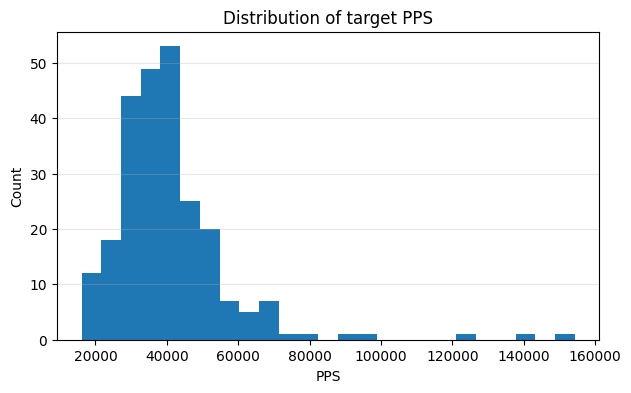

,target_pps
target_pps,1.000000
degree,0.496668
closeness,0.493992
pagerank,0.447834
weighted_degree,0.441194
core_number,0.415103
betweenness,0.383550
max_edge_distance,0.278376
traffic_per_neighbor,0.231941
mean_edge_distance,0.065193


In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(df_reg["target_pps"], bins=25)
plt.title("Distribution of target PPS")
plt.xlabel("PPS")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

corr_cols = [
    "target_pps",
    "degree",
    "weighted_degree",
    "traffic_per_neighbor",
    "pagerank",
    "closeness",
    "betweenness",
    "core_number",
    "mean_edge_distance",
    "max_edge_distance",
    "mean_neighbor_degree",
    "mean_neighbor_weighted_degree",
    "dist_to_europe_centroid",
]

corr_df = df_reg[corr_cols].corr(numeric_only=True)
corr_df[["target_pps"]].sort_values("target_pps", ascending=False)

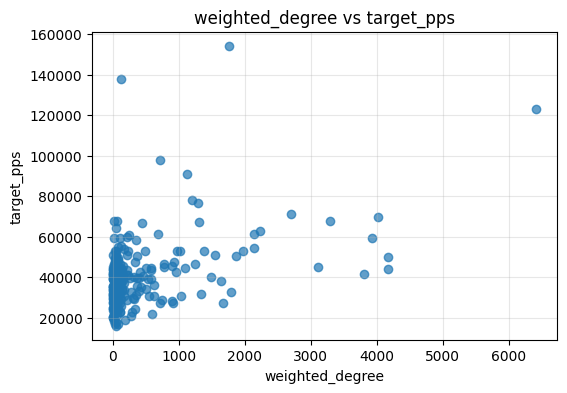

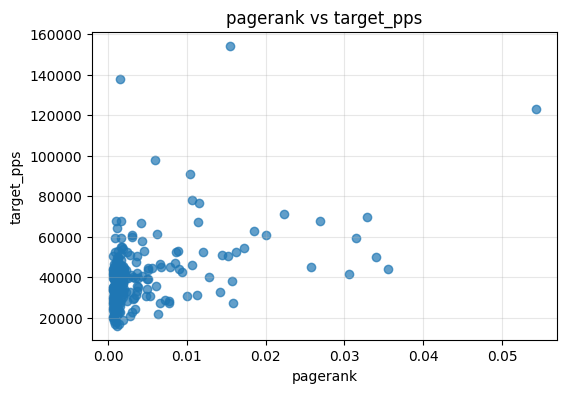

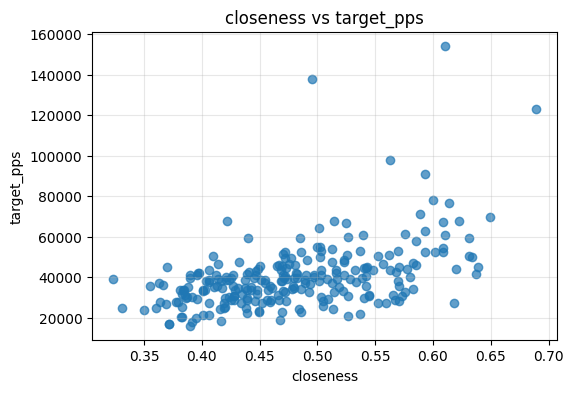

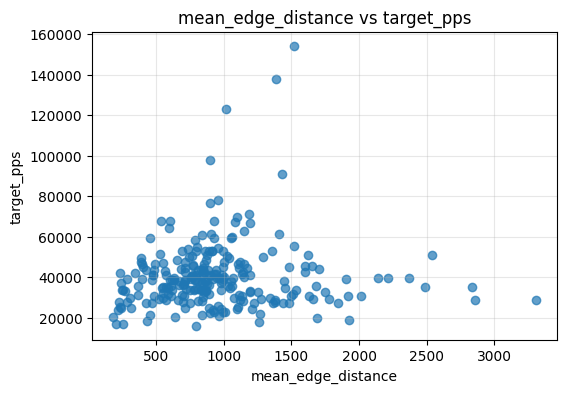

In [103]:
features_to_plot = [
    "weighted_degree",
    "pagerank",
    "closeness",
    "mean_edge_distance",
]

for col in features_to_plot:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_reg[col], df_reg["target_pps"], alpha=0.7)
    plt.xlabel(col)
    plt.ylabel("target_pps")
    plt.title(f"{col} vs target_pps")
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
# train test split

from sklearn.model_selection import GroupShuffleSplit

groups = df_reg["nut3_code"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_reg, groups=groups))

df_train = df_reg.iloc[train_idx].copy()
df_test = df_reg.iloc[test_idx].copy()

print("Train rows:", len(df_train))
print("Test rows:", len(df_test))
print("Train unique nut3:", df_train["nut3_code"].nunique())
print("Test unique nut3:", df_test["nut3_code"].nunique())

# leakage check
shared_groups = set(df_train["nut3_code"]).intersection(set(df_test["nut3_code"]))
print("Shared nut3 codes between train and test:", len(shared_groups))
assert len(shared_groups) == 0

Train rows: 190
Test rows: 57
Train unique nut3: 155
Test unique nut3: 39
Shared nut3 codes between train and test: 0


In [105]:
# Mean PPS by Louvain community computed ONLY on train
community_target_stats = (
    df_train.groupby("louvain_community")["target_pps"]
    .agg(["mean", "median", "count"])
    .reset_index()
    .rename(columns={
        "mean": "community_pps_mean_train",
        "median": "community_pps_median_train",
        "count": "community_train_count",
    })
)

global_train_mean_pps = df_train["target_pps"].mean()

df_train = df_train.merge(community_target_stats, on="louvain_community", how="left")
df_test = df_test.merge(community_target_stats, on="louvain_community", how="left")

# Fill unseen communities in test with global mean / safe defaults
for col in ["community_pps_mean_train", "community_pps_median_train"]:
    df_train[col] = df_train[col].fillna(global_train_mean_pps)
    df_test[col] = df_test[col].fillna(global_train_mean_pps)

df_train["community_train_count"] = df_train["community_train_count"].fillna(0)
df_test["community_train_count"] = df_test["community_train_count"].fillna(0)

display(df_train[[
    "id", "nut3_code", "louvain_community",
    "community_pps_mean_train", "community_pps_median_train", "community_train_count"
]].head())

,id,nut3_code,louvain_community,community_pps_mean_train,community_pps_median_train,community_train_count
0,"Tymbou (Kirklar), CY",CY000,5,43460.416667,44250.0,48
1,"Warsaw, PL",PL91,0,40277.083333,34150.0,48
2,"Skellefteå, SE",SE331,2,42675.000000,40350.0,24
3,"Memmingen, DE",DE27,0,40277.083333,34150.0,48
4,"Pisa (PI), IT",ITI1,0,40277.083333,34150.0,48


#### 2.2.1.2. Feature sets, helpers

In [106]:
target_col = "target_pps"

feature_set_A = [
    "degree",
    "weighted_degree",
    "traffic_per_neighbor",
    "clustering",
    "pagerank",
    "betweenness",
    "closeness",
    "core_number",
    "avg_neighbor_degree",
    "louvain_community_size",
]

feature_set_B = feature_set_A + [
    "latitude",
    "longitude",
    "dist_to_europe_centroid",
    "mean_edge_weight",
    "max_edge_weight",
    "std_edge_weight",
    "mean_edge_distance",
    "max_edge_distance",
    "std_edge_distance",
    "share_short_edges_300",
    "share_long_edges_500",
    "share_long_edges_1000",
    "mean_neighbor_degree",
    "mean_neighbor_weighted_degree",
    "mean_neighbor_pagerank",
    "mean_neighbor_latitude",
    "mean_neighbor_longitude",
]

feature_set_C = feature_set_B + [
    "community_pps_mean_train",
    "community_pps_median_train",
    "community_train_count",
]

In [110]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_regression(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

### 5.2.2. Linear Regression / Ridge / Gradient Boosting

In [111]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor

def run_regression_models(df_train, df_test, feature_cols, target_col, suffix=""):
    X_train = df_train[feature_cols].copy()
    y_train = df_train[target_col].copy()

    X_test = df_test[feature_cols].copy()
    y_test = df_test[target_col].copy()

    models = {
        f"LinearRegression{suffix}": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        f"Ridge{suffix}": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]),
        f"GradientBoosting{suffix}": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42,
            )),
        ]),
    }

    results = []
    fitted_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append(evaluate_regression(y_test, y_pred, name))
        fitted_models[name] = model

    return pd.DataFrame(results).sort_values("MAE"), fitted_models

In [112]:
results_A, models_A = run_regression_models(
    df_train, df_test, feature_set_A, target_col, suffix="_A_structural"
)

results_B, models_B = run_regression_models(
    df_train, df_test, feature_set_B, target_col, suffix="_B_structural_geo"
)

results_C, models_C = run_regression_models(
    df_train, df_test, feature_set_C, target_col, suffix="_C_plus_comm_mean"
)

results_all = pd.concat([results_A, results_B, results_C], ignore_index=True).sort_values("MAE")
results_all

,model,MAE,RMSE,R2
6,Ridge_C_plus_comm_mean,10672.926768,17924.832694,0.262328
3,Ridge_B_structural_geo,10769.466204,17962.556248,0.259220
7,LinearRegression_C_plus_comm_mean,11162.031975,18646.874193,0.201702
4,GradientBoosting_B_structural_geo,11190.680869,19245.819286,0.149595
5,LinearRegression_B_structural_geo,11192.855742,18392.308007,0.223350
8,GradientBoosting_C_plus_comm_mean,11402.756973,19374.647648,0.138172
0,Ridge_A_structural,12261.448993,19736.921901,0.105641
1,LinearRegression_A_structural,12716.286824,20032.207759,0.078680
2,GradientBoosting_A_structural,13958.964821,22962.773634,-0.210602


### 5.2.3. Results

In [113]:
best_model_name = results_all.iloc[0]["model"]

if best_model_name in models_A:
    best_model = models_A[best_model_name]
    best_features = feature_set_A
elif best_model_name in models_B:
    best_model = models_B[best_model_name]
    best_features = feature_set_B
else:
    best_model = models_C[best_model_name]
    best_features = feature_set_C

df_pred = df_test[["id", "nut3_code", "target_pps"]].copy()
df_pred["pred_pps"] = best_model.predict(df_test[best_features])
df_pred["abs_error"] = (df_pred["target_pps"] - df_pred["pred_pps"]).abs()

display(df_pred.sort_values("abs_error").head(15))
display(df_pred.sort_values("abs_error", ascending=False).head(15))

,id,nut3_code,target_pps,pred_pps,abs_error
29,"Funchal, PT",PT300,35300.0,35468.957346,168.957346
25,"Comiso, IT",ITG1,24500.0,23953.341617,546.658383
43,"Jyväskylän Maalaiskunta, FI",FI19,37000.0,38129.377469,1129.377469
47,"Ronneby, SE",SE221,38700.0,37245.260258,1454.739742
45,"Rota, ES",ES61,27400.0,28880.384985,1480.384985
16,"Ferno (VA), IT",ITC4,52700.0,54715.338112,2015.338112
18,"Caselle (VR), IT",ITH3,43400.0,41112.632423,2287.367577
39,"Segrate (MI), IT",ITC4,52700.0,55020.299280,2320.299280
5,"Montpellier/Méditerranée, FR",FRJ13,34100.0,36645.198751,2545.198751
41,"Stuttgart, DE",DE11,61300.0,58340.255770,2959.744230


,id,nut3_code,target_pps,pred_pps,abs_error
53,"Cork, IE",IE053,138000.0,42265.625239,95734.374761
46,"Paris, FR",FR101,123100.0,73539.573661,49560.426339
8,"Málaga, ES",ES61,27400.0,61648.255041,34248.255041
24,"Charleroi, BE",BE32,28800.0,55424.588674,26624.588674
20,"Eindhoven, NL",NL414,66600.0,44137.404090,22462.595910
1,"Riga, LV",LV00,27300.0,49045.253289,21745.253289
11,"Egelsbach, DE",DE71,59200.0,38055.744479,21144.255521
7,"Frankfurt am Main (Lautzenhausen), DE",DE71,59200.0,38723.454229,20476.545771
9,"Montichiari (BS), IT",ITC4,52700.0,34078.540991,18621.459009
31,"Seville, ES",ES61,27400.0,44326.697394,16926.697394


In [114]:
# feature importance for Gradient Boosting

for name, model in {**models_A, **models_B, **models_C}.items():
    if "GradientBoosting" in name:
        gb_model = model.named_steps["model"]

        if name in models_A:
            feature_cols = feature_set_A
        elif name in models_B:
            feature_cols = feature_set_B
        else:
            feature_cols = feature_set_C

        fi = pd.DataFrame({
            "feature": feature_cols,
            "importance": gb_model.feature_importances_,
        }).sort_values("importance", ascending=False)

        print(name)
        display(fi.head(20))

GradientBoosting_A_structural


,feature,importance
6,closeness,0.357535
1,weighted_degree,0.190312
5,betweenness,0.165625
2,traffic_per_neighbor,0.091283
8,avg_neighbor_degree,0.048503
3,clustering,0.043833
4,pagerank,0.036526
9,louvain_community_size,0.031332
0,degree,0.021536
7,core_number,0.013515


GradientBoosting_B_structural_geo


,feature,importance
6,closeness,0.295379
11,longitude,0.176673
5,betweenness,0.107639
20,share_long_edges_500,0.075599
10,latitude,0.071884
12,dist_to_europe_centroid,0.047164
1,weighted_degree,0.031626
25,mean_neighbor_latitude,0.031331
26,mean_neighbor_longitude,0.026313
0,degree,0.020860


GradientBoosting_C_plus_comm_mean


,feature,importance
6,closeness,0.290731
11,longitude,0.174338
5,betweenness,0.103852
20,share_long_edges_500,0.072873
10,latitude,0.072134
1,weighted_degree,0.038849
12,dist_to_europe_centroid,0.035961
25,mean_neighbor_latitude,0.032230
26,mean_neighbor_longitude,0.029374
0,degree,0.022767


### 5.2.4. Conclusion (written by chatgpt)

In this experiment, we considered the task of **predicting PPS per capita** from the cleaned undirected flight graph. Since several graph nodes correspond to the same **NUTS3** region and therefore share the same target value, the train/test split was performed by **NUTS3 code** rather than by individual node. This avoids target leakage and gives a more realistic estimate of generalization to unseen regions.

We evaluated three feature sets:

- **A: structural graph features only**
- **B: structural + geographic / distance features**
- **C: structural + geographic / distance features + train-only community mean PPS**

and compared three regression models for each set:

- **Linear Regression**
- **Ridge Regression**
- **Gradient Boosting Regressor**

The best result was obtained by **Ridge Regression with feature set C**, which achieved:

- **MAE = 10672.93**
- **RMSE = 17924.83**
- **R² = 0.262**

The second-best model was **Ridge Regression with feature set B**:

- **MAE = 10769.47**
- **RMSE = 17962.56**
- **R² = 0.259**

This is a very important result. It shows that **adding geographic and distance-aware features clearly improves performance** relative to the purely structural baseline, and that the additional **community-level train-only PPS feature** provides a small further gain.

The purely structural models performed noticeably worse. For example:

- **Ridge_A_structural** achieved **MAE = 12261.45** and **R² = 0.106**
- **LinearRegression_A_structural** achieved **MAE = 12716.29** and **R² = 0.079**

Thus, graph structure alone contains some predictive signal, but it is **not sufficient** to explain regional PPS well. The regression target is influenced not only by network centrality, but also by broader geographic and mesoscopic context.

Another important finding is that **Ridge Regression consistently outperformed both plain Linear Regression and Gradient Boosting**. In particular, the boosting model gave the weakest overall results, with **GradientBoosting_A_structural** even obtaining **negative R² (-0.211)**. This suggests that, for this dataset size and feature space, the more regularized linear model generalizes better than a more flexible nonlinear model.

Inspection of individual predictions also shows that the model works reasonably well for many ordinary regions, but struggles on strong economic outliers. For example, predictions for **Funchal**, **Comiso**, **Jyväskylä**, and **Ronneby** were quite accurate, while regions such as **Cork** and **Paris** produced very large errors. This indicates that the model captures broad structural-economic trends, but has difficulty with exceptional high-PPS regions whose economic profile is not fully explained by flight-network features alone.

Overall, this experiment shows that **PPS per capita can be predicted to some extent from graph-derived and geography-aware features**, but the signal is much weaker than in the airport class classification task. The best results were obtained when combining:

- graph structural descriptors,
- spatial / distance-based features,
- and a train-only community-level economic context feature.

This suggests that regional economic level is related not only to a node’s local position in the network, but also to the broader **spatial and mesoscopic structure** of the European air transportation graph. At the same time, the moderate R² values show that PPS is only partially determined by these factors, which makes this a substantially more difficult and realistic prediction task than node label classification.

## 5.3. Experiments with embedings: semantic node embeddings from edge embeddings

Is this message passing? **No**.

So what we built is closer to:
- one-step neighborhood aggregation
- manual message passing
- non-learned edge-to-node pooling

Our node embedding construction is conceptually related to message passing: each node aggregates semantic information from its incident edges, weighted by traffic intensity. However, unlike a graph neural network, this aggregation is not learned and is performed in a single step without iterative multi-hop propagation.

-----

In this section, we study **semantic node embeddings** derived from already prepared **edge embeddings** stored inside our domain `Graph`.

The idea is simple:

- each edge already contains a semantic feature vector,
- each city is connected to many edges,
- so we aggregate the semantic vectors of incident edges into one **node-level embedding**.

This gives us an interpretable representation of a city based on:
- airline composition,
- aircraft composition,
- traffic intensity,
- route distances,
- and coverage-related features.


We load the prepared undirected graph that already contains edge embeddings.

This is important because we do **not** rebuild features from scratch here. Instead, we directly use the graph as the main domain object and perform the experiment on top of it.

In [21]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

from graph_creation.adapters.input import GraphJsonLoader

gr = GraphJsonLoader().load("./final_graphs_data/gr_for_edges_embeddings_ready/gr_for_edges_embeddings_ready.json")
gr

Graph(type=UNDIRECTED, nodes=101, edges=894, flights=57069, countries=29, begin=2026-02-16 00:00:00 UTC, end=2026-02-22 23:59:59 UTC)

Friendly reminder:

Each edge embedding is stored as a vector, and `gr.edge_embedding_columns` defines the semantic meaning of each coordinate.

The embedding contains:
- airline-group shares,
- aircraft-group shares,
- coverage features,
- and traffic-scale features.

So, the edge embedding is not a black-box latent vector, but an **interpretable semantic vector**.

In [5]:
gr.edge_embedding_columns

['pct_lufthansa_group',
 'pct_air_france_klm_group',
 'pct_iag_group',
 'pct_nordic_legacy',
 'pct_mediterranean_legacy',
 'pct_turkish_and_south_east_legacy',
 'pct_ryanair_group',
 'pct_easyjet_group',
 'pct_wizz_group',
 'pct_other_low_cost_leisure',
 'pct_cargo',
 'pct_other_specialized',
 'pct_narrowbody_airbus',
 'pct_narrowbody_boeing',
 'pct_widebody',
 'pct_regional',
 'pct_business_jet',
 'operator_coverage',
 'aircraft_coverage',
 'log_total_flights',
 'log_unique_callsigns']

In [ ]:
sum(1 for e in gr.edges if e.embeddings is not None) == 894 # no nans, all 894 edges have embeddings

True

### 5.3.1. Node embeddings aggreagation

We create helpers / utils:
- a fast `node_by_id` lookup,
- the ordered list of embedding columns,
- and the embedding dimensionality.

The embedding dimension is **21**, which means that each route is represented by 21 semantic features.

In [ ]:
node_by_id = {n.id: n for n in gr.nodes}
embedding_cols = list(gr.edge_embedding_columns)
emb_dim = len(embedding_cols)

print("Embedding dimension:", emb_dim)

def weighted_mean_matrix(X, w):
    w = np.asarray(w, dtype=float).reshape(-1, 1)
    denom = np.maximum(w.sum(), 1e-12)
    return (X * w).sum(axis=0) / denom


def weighted_std_matrix(X, w):
    mu = weighted_mean_matrix(X, w)
    w = np.asarray(w, dtype=float).reshape(-1, 1)
    denom = np.maximum(w.sum(), 1e-12)
    var = (w * (X - mu) ** 2).sum(axis=0) / denom
    return np.sqrt(var)


def safe_entropy(values):
    x = np.asarray(values, dtype=float)
    total = x.sum()
    if total <= 0:
        return 0.0
    x = x / total
    x = np.clip(x, 1e-12, None)
    return -(x * np.log(x)).sum()


def long_route_share(distances, weights, threshold=1000):
    distances = np.asarray(distances, dtype=float)
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()
    if total <= 0:
        return 0.0
    return weights[distances > threshold].sum() / total

Embedding dimension: 21


To make later interpretation easier, we separate the embedding coordinates into logical groups:

- **airline columns** — airline-family structure of a route,
- **aircraft columns** — aircraft-type structure of a route,
- **coverage columns** — how complete operator/aircraft identification is,
- **size columns** — route activity proxies such as log flights and log callsigns.

This grouping is useful because later we want not only a numeric embedding, but also a human-readable city profile.

In [9]:
airline_cols = [c for c in embedding_cols if c.startswith("pct_") and c not in {
    "pct_narrowbody_airbus",
    "pct_narrowbody_boeing",
    "pct_widebody",
    "pct_regional",
    "pct_business_jet",
}]

aircraft_cols = [
    c for c in embedding_cols
    if c in {
        "pct_narrowbody_airbus",
        "pct_narrowbody_boeing",
        "pct_widebody",
        "pct_regional",
        "pct_business_jet",
    }
]

coverage_cols = [c for c in embedding_cols if c in {"operator_coverage", "aircraft_coverage"}]
size_cols = [c for c in embedding_cols if c in {"log_total_flights", "log_unique_callsigns"}]

print("Airline columns:", airline_cols)
print("Aircraft columns:", aircraft_cols)
print("Coverage columns:", coverage_cols)
print("Size columns:", size_cols)

Airline columns: ['pct_lufthansa_group', 'pct_air_france_klm_group', 'pct_iag_group', 'pct_nordic_legacy', 'pct_mediterranean_legacy', 'pct_turkish_and_south_east_legacy', 'pct_ryanair_group', 'pct_easyjet_group', 'pct_wizz_group', 'pct_other_low_cost_leisure', 'pct_cargo', 'pct_other_specialized']
Aircraft columns: ['pct_narrowbody_airbus', 'pct_narrowbody_boeing', 'pct_widebody', 'pct_regional', 'pct_business_jet']
Coverage columns: ['operator_coverage', 'aircraft_coverage']
Size columns: ['log_total_flights', 'log_unique_callsigns']



To construct a node embedding, each node must “see” all of its adjacent routes.

Because the graph is undirected, every edge contributes to **both endpoints**:
- once from node A to node B,
- and once from node B to node A.

This produces an incident-edge table with **1788 rows**, which is exactly twice the number of graph edges.

In [ ]:
incident_rows = []

for e in gr.edges:
    if e.embeddings is None:
        continue

    vec = np.asarray(e.embeddings, dtype=float)
    if len(vec) != emb_dim:
        raise ValueError(f"Embedding length mismatch for edge {e.from_id} -- {e.to_id}")

    for node_id, neighbor_id in [(e.from_id, e.to_id), (e.to_id, e.from_id)]:
        incident_rows.append({
            "node": node_id,
            "neighbor": neighbor_id,
            "weight": e.weight,
            "distance": e.distance,
            "embedding": vec,
        })

print("Incident rows:", len(incident_rows))
incident_rows[:2]

Incident rows: 1788


[{'node': 'Aberdeen, GB',
  'neighbor': 'Stavanger, NO',
  'weight': 35,
  'distance': 497.01,
  'embedding': array([0.        , 0.        , 0.        , 1.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         1.        , 0.        , 0.54285714, 0.48571429, 3.58351894,
         2.19722458])},
 {'node': 'Stavanger, NO',
  'neighbor': 'Aberdeen, GB',
  'weight': 35,
  'distance': 497.01,
  'embedding': array([0.        , 0.        , 0.        , 1.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         1.        , 0.        , 0.54285714, 0.48571429, 3.58351894,
         2.19722458])}]

This is the core step of the experiment - **aggregation of edge embeddings into node embeddings**

For each city, we aggregate the embeddings of all incident routes using edge weight as importance. We compute:

- weighted mean embedding,
- weighted standard deviation,
- maximum activation per feature,
- route-distance summaries,
- long-route shares,
- entropy-based diversity measures,
- dominant airline group,
- dominant aircraft group.

As a result, we obtain a node-level table with **101 cities** and **82 columns**.

So each city is now represented by an interpretable semantic embedding that summarizes its traffic profile.

In [ ]:
rows = []

grouped = defaultdict(list)
for row in incident_rows:
    grouped[row["node"]].append(row)

for node_id, items in grouped.items():
    weights = np.array([x["weight"] for x in items], dtype=float)
    distances = np.array([x["distance"] for x in items], dtype=float)
    X = np.vstack([x["embedding"] for x in items])

    mean_vec = weighted_mean_matrix(X, weights)
    std_vec = weighted_std_matrix(X, weights)
    max_vec = X.max(axis=0)

    row = {
        "node": node_id,
        "degree": len(items),
        "weighted_degree": weights.sum(),
        "mean_distance": np.average(distances, weights=weights),
        "median_distance": float(np.median(distances)),
        "share_long_routes_1000km": long_route_share(distances, weights, threshold=1000),
        "share_long_routes_1500km": long_route_share(distances, weights, threshold=1500),
    }

    node_obj = node_by_id.get(node_id)
    if node_obj is not None:
        row["iso_country"] = node_obj.iso_country
        row["iso_region"] = node_obj.iso_region
        row["node_type"] = node_obj.node_type
        row["traffic"] = node_obj.traffic
        row["latitude"] = node_obj.latitude
        row["longitude"] = node_obj.longitude

    for col, val in zip(embedding_cols, mean_vec):
        row[f"mean_{col}"] = float(val)

    for col, val in zip(embedding_cols, std_vec):
        row[f"std_{col}"] = float(val)

    for col, val in zip(embedding_cols, max_vec):
        row[f"max_{col}"] = float(val)

    if airline_cols:
        airline_profile = np.array([row[f"mean_{c}"] for c in airline_cols], dtype=float)
        row["airline_entropy"] = safe_entropy(airline_profile)
        row["dominant_airline_group"] = airline_cols[int(np.argmax(airline_profile))]
        row["dominant_airline_share"] = (
            airline_profile.max() / airline_profile.sum()
            if airline_profile.sum() > 0 else 0.0
        )

    if aircraft_cols:
        aircraft_profile = np.array([row[f"mean_{c}"] for c in aircraft_cols], dtype=float)
        row["aircraft_entropy"] = safe_entropy(aircraft_profile)
        row["dominant_aircraft_group"] = aircraft_cols[int(np.argmax(aircraft_profile))]
        row["dominant_aircraft_share"] = (
            aircraft_profile.max() / aircraft_profile.sum()
            if aircraft_profile.sum() > 0 else 0.0
        )

    rows.append(row)

node_embeddings_df = pd.DataFrame(rows).sort_values("node").reset_index(drop=True)

print(node_embeddings_df.shape)
display(node_embeddings_df.head())

(101, 82)


,node,degree,weighted_degree,mean_distance,median_distance,share_long_routes_1000km,share_long_routes_1500km,iso_country,iso_region,node_type,...,max_operator_coverage,max_aircraft_coverage,max_log_total_flights,max_log_unique_callsigns,airline_entropy,dominant_airline_group,dominant_airline_share,aircraft_entropy,dominant_aircraft_group,dominant_aircraft_share
0,"Aberdeen, GB",7,329.0,592.086809,528.740,0.000000,0.000000,GB,GB-SCT,medium,...,1.000000,0.960000,4.912655,3.465736,1.073967,pct_other_specialized,0.614955,0.820260,pct_regional,0.550788
1,"Alicante, ES",27,1167.0,1468.880034,1578.500,0.838903,0.550129,ES,ES-VC,large,...,1.000000,1.000000,4.955827,3.526361,1.468696,pct_ryanair_group,0.352645,0.865658,pct_narrowbody_boeing,0.522674
2,"Almería, ES",3,87.0,441.617241,414.840,0.000000,0.000000,ES,ES-AN,medium,...,0.809524,0.904762,3.806662,2.639057,0.486289,pct_other_specialized,0.809955,0.731578,pct_regional,0.690054
3,"Amsterdam, NL",74,5317.0,850.066502,784.635,0.284559,0.118112,NL,NL-NH,large,...,1.000000,1.000000,6.204558,4.852030,1.479275,pct_air_france_klm_group,0.607058,1.228943,pct_narrowbody_airbus,0.384860
4,"Antalya, TR",3,384.0,840.600807,2478.710,0.158854,0.158854,TR,TR-07,large,...,0.755418,0.875000,5.780744,4.564348,0.282259,pct_turkish_and_south_east_legacy,0.935185,0.811738,pct_narrowbody_airbus,0.535343


The resulting node embedding table already looks meaningful.

For example, major hubs such as **Amsterdam** have:
- high degree,
- high weighted degree,
- and a richer mixture of route semantics.

This confirms that the aggregation captures both:
- the size of the node in the traffic network,
- and the composition of its surrounding routes.

### 5.3.2 PCA and clustering with KMeans
Next, we select the numerical features used for similarity analysis, PCA, and clustering.

The final matrix has shape **(101, 74)**:
- 101 nodes,
- 74 node-level features.

This is our final semantic representation space for the embedding experiment.

In [13]:
# final ML feature matrix

feature_cols = [
    "degree",
    "weighted_degree",
    "mean_distance",
    "median_distance",
    "share_long_routes_1000km",
    "share_long_routes_1500km",
]

feature_cols += [c for c in node_embeddings_df.columns if c.startswith("mean_")]
feature_cols += [c for c in node_embeddings_df.columns if c.startswith("std_")]
feature_cols += [c for c in node_embeddings_df.columns if c.startswith("max_")]

if "airline_entropy" in node_embeddings_df.columns:
    feature_cols.append("airline_entropy")
if "aircraft_entropy" in node_embeddings_df.columns:
    feature_cols.append("aircraft_entropy")
if "dominant_airline_share" in node_embeddings_df.columns:
    feature_cols.append("dominant_airline_share")
if "dominant_aircraft_share" in node_embeddings_df.columns:
    feature_cols.append("dominant_aircraft_share")

X = node_embeddings_df[feature_cols].fillna(0.0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)
print("Number of features:", len(feature_cols))

Feature matrix shape: (101, 74)
Number of features: 74


Explained variance ratio: [0.16195203 0.12166614]
Total explained variance: 0.2836181761570532


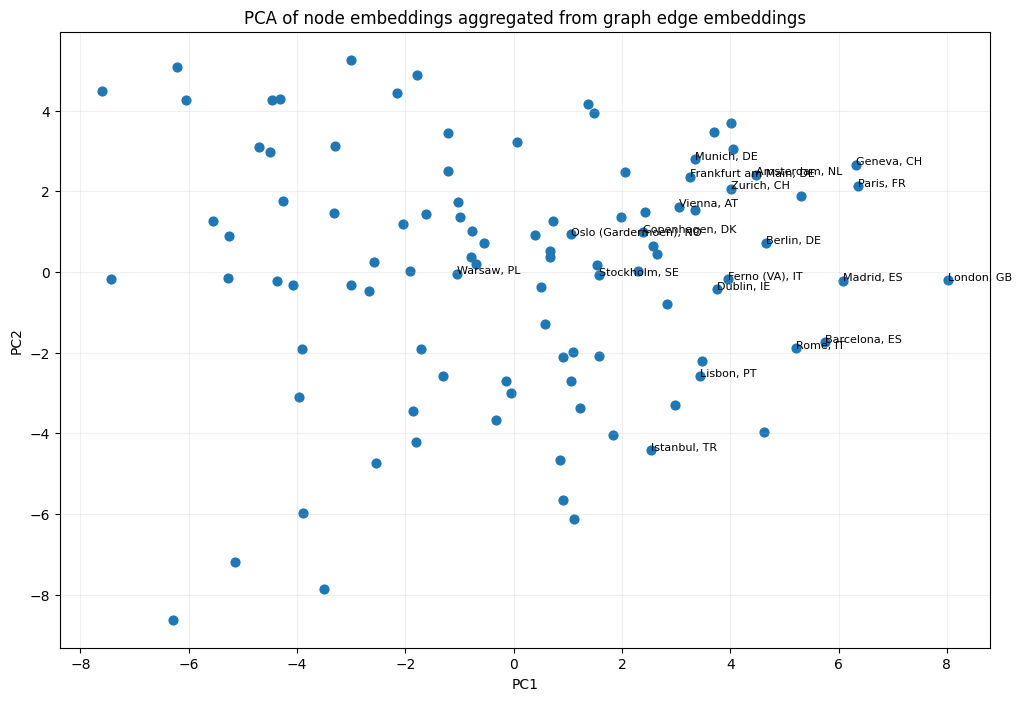

In [14]:
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X_scaled)

node_embeddings_df["x_pca"] = coords_2d[:, 0]
node_embeddings_df["y_pca"] = coords_2d[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(12, 8))
plt.scatter(node_embeddings_df["x_pca"], node_embeddings_df["y_pca"], s=40)

top_nodes = node_embeddings_df.nlargest(20, "weighted_degree")
for _, r in top_nodes.iterrows():
    plt.text(r["x_pca"], r["y_pca"], r["node"], fontsize=8)

plt.title("PCA of node embeddings aggregated from graph edge embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.show()

PCA is used here for visualization rather than for modeling.

The first two principal components explain about **28.4%** of the variance:
- PC1: 16.2%
- PC2: 12.2%

This is not extremely high, but it is enough to obtain a useful two-dimensional map of the semantic embedding space and inspect whether similar cities tend to appear close to one another.

-----

The PCA projection shows that the semantic embedding space is structured rather than random.

Large and semantically rich cities tend to occupy distinct positions, while more similar regional or specialized nodes appear closer to one another.

This suggests that the aggregated node embeddings preserve meaningful differences in route composition.


----

We apply **KMeans with 5 clusters** to the node embeddings in order to identify broad types of cities with similar aviation profiles.

This is an unsupervised way to test whether the embedding space contains meaningful structure.

In [15]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
node_embeddings_df["semantic_cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    node_embeddings_df.groupby("semantic_cluster")
    .agg(
        n_nodes=("node", "count"),
        avg_weighted_degree=("weighted_degree", "mean"),
        avg_mean_distance=("mean_distance", "mean"),
        avg_long_routes=("share_long_routes_1000km", "mean"),
        avg_airline_entropy=("airline_entropy", "mean") if "airline_entropy" in node_embeddings_df.columns else ("degree", "mean"),
        avg_aircraft_entropy=("aircraft_entropy", "mean") if "aircraft_entropy" in node_embeddings_df.columns else ("degree", "mean"),
    )
    .sort_values("avg_weighted_degree", ascending=False)
)

display(cluster_summary)

,n_nodes,avg_weighted_degree,avg_mean_distance,avg_long_routes,avg_airline_entropy,avg_aircraft_entropy
semantic_cluster,,,,,,
0,33,2340.636364,886.879091,0.327564,1.717492,0.943346
1,14,950.500000,1421.539140,0.728083,1.317395,0.745264
2,25,485.880000,755.523985,0.212073,1.140323,0.860386
4,23,412.478261,629.668791,0.156897,0.977747,0.902809
3,6,326.000000,758.565600,0.261844,1.075972,0.923618


The cluster statistics show clear semantic differences between groups.

A few patterns stand out:

- **Cluster 0** has the largest average weighted degree and relatively high entropy.  
  This looks like a group of major, diverse hubs.

- **Cluster 1** has the highest average route distance and the highest long-route share.  
  This likely corresponds to more long-haul or tourism-oriented profiles.

- **Clusters 2 and 4** have lower weighted degree and shorter average routes.  
  These look more like regional or medium-sized traffic profiles.

- **Cluster 3** is very small, which suggests a compact niche group of nodes with a distinct semantic signature.

Overall, clustering confirms that the node embeddings separate different traffic roles in a meaningful way.

-----

We now plot the discovered clusters on the PCA projection.

This makes it easier to see whether the unsupervised grouping aligns with the visible structure of the embedding space and whether high-traffic cities behave like separate semantic centers.

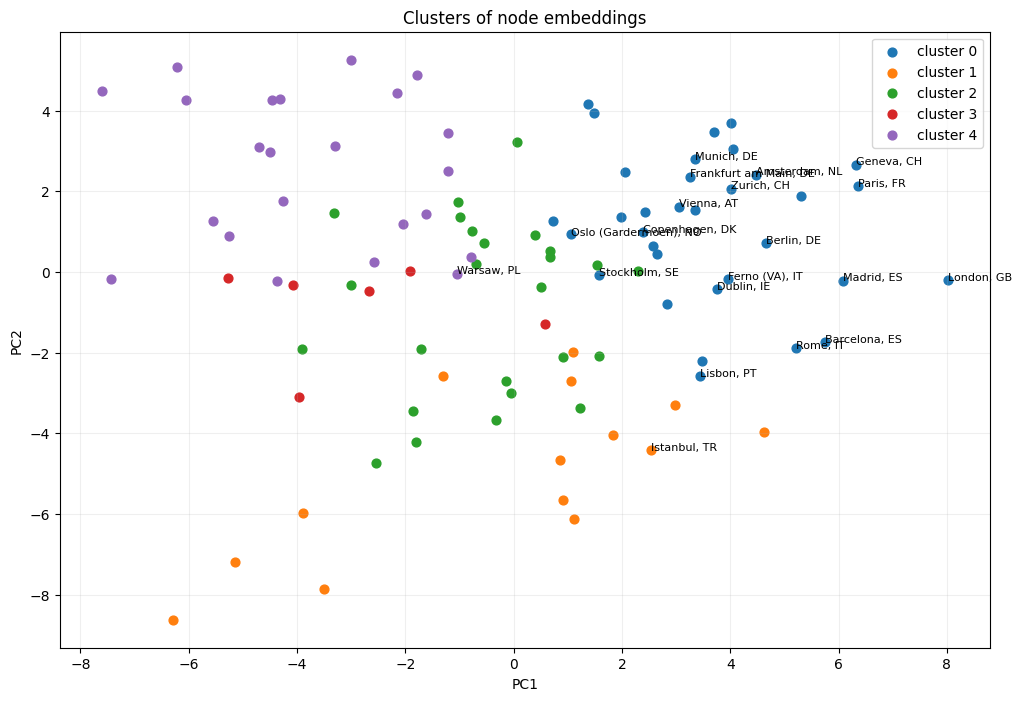

In [16]:
plt.figure(figsize=(12, 8))
for cluster_id, g in node_embeddings_df.groupby("semantic_cluster"):
    plt.scatter(g["x_pca"], g["y_pca"], s=40, label=f"cluster {cluster_id}")

for _, r in top_nodes.iterrows():
    plt.text(r["x_pca"], r["y_pca"], r["node"], fontsize=8)

plt.title("Clusters of node embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

The cluster visualization shows that several groups occupy different regions of the embedding space.

The separation is not perfectly sharp, which is normal for real transport data, but the plot still supports the idea that semantic node embeddings capture broad traffic archetypes:
- large hubs,
- long-distance profiles,
- and more regional structures.

### 5.3.3. Evaluating semantic node embeddings

To evaluate whether the embeddings behave sensibly, we compute **cosine similarity** between node vectors.

This lets us answer the question:

> Which cities have the most similar semantic flight profile?

For a good embedding, nearest neighbors should be plausible from an aviation-network perspective.

In [18]:
sim = cosine_similarity(X_scaled)
sim_df = pd.DataFrame(
    sim,
    index=node_embeddings_df["node"],
    columns=node_embeddings_df["node"],
)

def get_nearest_neighbors(node_name, top_k=5):
    scores = sim_df.loc[node_name].drop(node_name).sort_values(ascending=False).head(top_k)
    return pd.DataFrame({
        "neighbor": scores.index,
        "cosine_similarity": scores.values,
    })

# example
display(get_nearest_neighbors("Amsterdam, NL", top_k=8))

,neighbor,cosine_similarity
0,"Paris, FR",0.709999
1,"London, GB",0.520433
2,"Toulouse/Blagnac, FR",0.469167
3,"Marignane, Bouches-du-Rhône, FR",0.416169
4,"Geneva, CH",0.403383
5,"Madrid, ES",0.372195
6,"Zurich, CH",0.366665
7,"Barcelona, ES",0.363568


For the inspected example, the nearest neighbors are highly plausible:
Paris, London, Toulouse/Blagnac, Marseille, Geneva, Madrid, Zurich, and Barcelona.

This is a strong qualitative result. It suggests that the embedding does not simply memorize graph size, but captures a broader semantic profile related to:
- airline composition,
- aircraft mix,
- and route structure.

-----

Finally, we turn the numeric embedding into an interpretable city description.

This step is especially useful for the report because it connects the abstract vector representation with concrete aviation meaning:
- route length profile,
- dominant airline family,
- dominant aircraft family,
- and nearest semantic neighbors

In [20]:
def city_profile(node_name, top_k_neighbors=5):
    r = node_embeddings_df.loc[node_embeddings_df["node"] == node_name]
    if len(r) == 0:
        raise KeyError(f"{node_name} not found")
    r = r.iloc[0]

    result = {
        "node": node_name,
        "degree": int(r["degree"]),
        "weighted_degree": float(r["weighted_degree"]),
        "mean_distance": float(r["mean_distance"]),
        "share_long_routes_1000km": float(r["share_long_routes_1000km"]),
        "semantic_cluster": int(r["semantic_cluster"]),
        "nearest_neighbors": get_nearest_neighbors(node_name, top_k=top_k_neighbors).to_dict(orient="records"),
    }

    if airline_cols:
        airline_mix = (
            pd.Series({c: r[f"mean_{c}"] for c in airline_cols})
            .sort_values(ascending=False)
            .head(3)
        )
        result["dominant_airline_group"] = r.get("dominant_airline_group")
        result["top_airline_groups"] = airline_mix.to_dict()

    if aircraft_cols:
        aircraft_mix = (
            pd.Series({c: r[f"mean_{c}"] for c in aircraft_cols})
            .sort_values(ascending=False)
            .head(3)
        )
        result["dominant_aircraft_group"] = r.get("dominant_aircraft_group")
        result["top_aircraft_groups"] = aircraft_mix.to_dict()

    return result


def print_city_profile(node_name, top_k_neighbors=5):
    p = city_profile(node_name, top_k_neighbors=top_k_neighbors)

    print(f"\nCity: {p['node']}")
    print(f"- degree: {p['degree']}")
    print(f"- weighted degree: {p['weighted_degree']:.1f}")
    print(f"- mean route distance: {p['mean_distance']:.1f} km")
    print(f"- share of long routes >1000 km: {p['share_long_routes_1000km']:.3f}")
    print(f"- cluster: {p['semantic_cluster']}")

    if "dominant_airline_group" in p:
        print(f"- dominant airline group: {p['dominant_airline_group']}")
        print("- top airline groups:")
        for k, v in p["top_airline_groups"].items():
            print(f"    {k}: {v:.3f}")

    if "dominant_aircraft_group" in p:
        print(f"- dominant aircraft group: {p['dominant_aircraft_group']}")
        print("- top aircraft groups:")
        for k, v in p["top_aircraft_groups"].items():
            print(f"    {k}: {v:.3f}")

    print("- nearest neighbors:")
    for item in p["nearest_neighbors"]:
        print(f"    {item['neighbor']}: {item['cosine_similarity']:.3f}")

# examples
print_city_profile("Amsterdam, NL", top_k_neighbors=5)


City: Amsterdam, NL
- degree: 74
- weighted degree: 5317.0
- mean route distance: 850.1 km
- share of long routes >1000 km: 0.285
- cluster: 0
- dominant airline group: pct_air_france_klm_group
- top airline groups:
    pct_air_france_klm_group: 0.597
    pct_easyjet_group: 0.103
    pct_other_low_cost_leisure: 0.072
- dominant aircraft group: pct_narrowbody_airbus
- top aircraft groups:
    pct_narrowbody_airbus: 0.385
    pct_regional: 0.298
    pct_narrowbody_boeing: 0.279
- nearest neighbors:
    Paris, FR: 0.710
    London, GB: 0.520
    Toulouse/Blagnac, FR: 0.469
    Marignane, Bouches-du-Rhône, FR: 0.416
    Geneva, CH: 0.403


Amsterdam has:

- very high degree (**74**) and weighted degree (**5317**),
- medium-to-high average route distance (**850 km**),
- a moderate long-route share (**0.285**),
- dominant **Air France–KLM group** presence,
- and a mainly **narrowbody Airbus / regional / narrowbody Boeing** aircraft mix.

Its nearest semantic neighbors are:
- Paris,
- London,
- Toulouse/Blagnac,
- Marseille,
- Geneva.

This is a convincing result. Amsterdam is recognized as a large, diversified Western European hub with a strong legacy-carrier profile and a route structure similar to other major European aviation centers.


### 5.3.4. Conclusion (written by chat gpt)

In this experiment, we transformed **edge-level semantic embeddings** into **node-level semantic embeddings** by aggregating the embeddings of incident routes for each city.

This approach worked well for several reasons:

1. **It respects the domain model**  
   We used the graph object directly and relied on embeddings already attached to edges.

2. **It is interpretable**  
   The resulting node embeddings are not opaque latent vectors. They can be explained using airline composition, aircraft composition, route length, coverage, and traffic intensity.

3. **It captures meaningful structure**  
   PCA showed non-random organization of cities in embedding space, and KMeans identified several distinct semantic groups.

4. **It gives plausible semantic similarity results**  
   Nearest-neighbor analysis produced convincing results. For example, Amsterdam was closest to other major Western European hubs, which matches aviation intuition.

5. **It is useful for further ML or qualitative analysis**  
   These node embeddings can now be reused for:
   - clustering,
   - similarity search,
   - city profiling,
   - and downstream supervised ML tasks.

Overall, this experiment shows that aggregating route semantics into city semantics is a strong and explainable way to represent nodes in the European flights graph. The embeddings preserve both structural importance and traffic composition, making them a valuable final representation for the project.